In [1]:
import pandas as pd
from flaml import AutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
import numpy as np
import shap
import matplotlib.pyplot as plt
import re
import json
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# ==== 5-Fold KFold CV ====
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

### Hurricane

In [2]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Hurricane_Regression_data_high.csv")  # Adjust path if needed

### Without Disaster Variables

In [3]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Disaster_Count","Disaster_Dmg","Disaster_Fatality","Disaster_Injury"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 03-30 19:50:43] {1728} INFO - task = regression
[flaml.automl.logger: 03-30 19:50:43] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 03-30 19:50:43] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 03-30 19:50:43] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 03-30 19:50:43] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-30 19:50:43] {2393} INFO - Estimated sufficient time budget=1839s. Estimated necessary time budget=10s.
[flaml.automl.logger: 03-30 19:50:43] {2442} INFO -  at 0.2s,	estimator xgboost's best error=8.7971,	best estimator xgboost's best error=8.7971
[flaml.automl.logger: 03-30 19:50:43] {2258} INFO - iteration 1, current learner lgbm


ValueError: Unable to avoid copy while creating an array as requested.
If using `np.array(obj, copy=False)` replace it with `np.asarray(obj)` to allow a copy when needed (no behavior change in NumPy 1.x).
For more details, see https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword.

In [ ]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")


In [ ]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


In [ ]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


## With Disaster Variables

In [7]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 15:17:32] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 15:17:32] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 15:17:32] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 15:17:32] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 15:17:32] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 15:17:33] {2393} INFO - Estimated sufficient time budget=3431s. Estimated necessary time budget=19s.
[flaml.automl.logger: 09-18 15:17:33] {2442} INFO -  at 0.4s,	estimator xgboost's best error=8.7971,	best estimator xgboost's best error=8.7971
[flaml.automl.logger: 09-18 15:17:33] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 15:17:33] {2442} INFO -  at 0.6s,	estimator lgbm's best error=8.8876,	best estimator xgboost's best error=8.7971
[flaml.automl.logg

[flaml.automl.logger: 09-18 15:17:41] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 15:17:41] {2442} INFO -  at 8.6s,	estimator histgb's best error=6.6698,	best estimator histgb's best error=6.6698
[flaml.automl.logger: 09-18 15:17:41] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 09-18 15:17:41] {2442} INFO -  at 9.2s,	estimator extra_tree's best error=7.4611,	best estimator histgb's best error=6.6698
[flaml.automl.logger: 09-18 15:17:41] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 15:17:41] {2442} INFO -  at 9.3s,	estimator histgb's best error=6.6698,	best estimator histgb's best error=6.6698
[flaml.automl.logger: 09-18 15:17:41] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 15:17:42] {2442} INFO -  at 9.4s,	estimator histgb's best error=6.6698,	best estimator histgb's best error=6.6698
[flaml.automl.logger: 09-18 15:17:42] {2258} INFO - iteration 38, cu

[flaml.automl.logger: 09-18 15:17:53] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 09-18 15:17:54] {2442} INFO -  at 21.5s,	estimator histgb's best error=6.6698,	best estimator lgbm's best error=6.6485
[flaml.automl.logger: 09-18 15:17:54] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 15:17:54] {2442} INFO -  at 21.6s,	estimator histgb's best error=6.6698,	best estimator lgbm's best error=6.6485
[flaml.automl.logger: 09-18 15:17:54] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 09-18 15:17:54] {2442} INFO -  at 21.7s,	estimator histgb's best error=6.6698,	best estimator lgbm's best error=6.6485
[flaml.automl.logger: 09-18 15:17:54] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 09-18 15:17:54] {2442} INFO -  at 21.7s,	estimator histgb's best error=6.6698,	best estimator lgbm's best error=6.6485
[flaml.automl.logger: 09-18 15:17:54] {2258} INFO - iteration 74, current learne

[flaml.automl.logger: 09-18 15:18:00] {2258} INFO - iteration 106, current learner histgb
[flaml.automl.logger: 09-18 15:18:00] {2442} INFO -  at 27.8s,	estimator histgb's best error=6.4777,	best estimator histgb's best error=6.4777
[flaml.automl.logger: 09-18 15:18:00] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 09-18 15:18:00] {2442} INFO -  at 27.9s,	estimator histgb's best error=6.4777,	best estimator histgb's best error=6.4777
[flaml.automl.logger: 09-18 15:18:00] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 09-18 15:18:00] {2442} INFO -  at 28.0s,	estimator histgb's best error=6.4777,	best estimator histgb's best error=6.4777
[flaml.automl.logger: 09-18 15:18:00] {2258} INFO - iteration 109, current learner histgb
[flaml.automl.logger: 09-18 15:18:00] {2442} INFO -  at 28.1s,	estimator histgb's best error=6.4777,	best estimator histgb's best error=6.4777
[flaml.automl.logger: 09-18 15:18:00] {2258} INFO - iteration 110, c

[flaml.automl.logger: 09-18 15:18:09] {2442} INFO -  at 36.6s,	estimator histgb's best error=6.4477,	best estimator histgb's best error=6.4477
[flaml.automl.logger: 09-18 15:18:09] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 09-18 15:18:09] {2442} INFO -  at 36.6s,	estimator histgb's best error=6.4477,	best estimator histgb's best error=6.4477
[flaml.automl.logger: 09-18 15:18:09] {2258} INFO - iteration 143, current learner histgb
[flaml.automl.logger: 09-18 15:18:09] {2442} INFO -  at 36.7s,	estimator histgb's best error=6.4477,	best estimator histgb's best error=6.4477
[flaml.automl.logger: 09-18 15:18:09] {2258} INFO - iteration 144, current learner histgb
[flaml.automl.logger: 09-18 15:18:09] {2442} INFO -  at 36.9s,	estimator histgb's best error=6.4477,	best estimator histgb's best error=6.4477
[flaml.automl.logger: 09-18 15:18:09] {2258} INFO - iteration 145, current learner histgb
[flaml.automl.logger: 09-18 15:18:09] {2442} INFO -  at 36.9s,	estim

...

[flaml.automl.logger: 09-18 15:26:50] {2258} INFO - iteration 1230, current learner histgb
[flaml.automl.logger: 09-18 15:26:50] {2442} INFO -  at 558.2s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:50] {2258} INFO - iteration 1231, current learner histgb
[flaml.automl.logger: 09-18 15:26:50] {2442} INFO -  at 558.3s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:50] {2258} INFO - iteration 1232, current learner histgb
[flaml.automl.logger: 09-18 15:26:50] {2442} INFO -  at 558.4s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:50] {2258} INFO - iteration 1233, current learner histgb
[flaml.automl.logger: 09-18 15:26:51] {2442} INFO -  at 558.6s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:51] {2258} INFO - iteratio

[flaml.automl.logger: 09-18 15:26:56] {2258} INFO - iteration 1265, current learner histgb
[flaml.automl.logger: 09-18 15:26:56] {2442} INFO -  at 564.2s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:56] {2258} INFO - iteration 1266, current learner histgb
[flaml.automl.logger: 09-18 15:26:56] {2442} INFO -  at 564.4s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:56] {2258} INFO - iteration 1267, current learner rf
[flaml.automl.logger: 09-18 15:26:57] {2442} INFO -  at 565.4s,	estimator rf's best error=6.5848,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:57] {2258} INFO - iteration 1268, current learner histgb
[flaml.automl.logger: 09-18 15:26:58] {2442} INFO -  at 565.5s,	estimator histgb's best error=6.2701,	best estimator histgb's best error=6.2701
[flaml.automl.logger: 09-18 15:26:58] {2258} INFO - iteration 1269, 

[flaml.automl.logger: 09-18 15:27:06] {2258} INFO - iteration 1300, current learner histgb
[flaml.automl.logger: 09-18 15:27:06] {2442} INFO -  at 574.1s,	estimator histgb's best error=6.2536,	best estimator histgb's best error=6.2536
[flaml.automl.logger: 09-18 15:27:06] {2258} INFO - iteration 1301, current learner histgb
[flaml.automl.logger: 09-18 15:27:06] {2442} INFO -  at 574.2s,	estimator histgb's best error=6.2536,	best estimator histgb's best error=6.2536
[flaml.automl.logger: 09-18 15:27:06] {2258} INFO - iteration 1302, current learner histgb
[flaml.automl.logger: 09-18 15:27:06] {2442} INFO -  at 574.3s,	estimator histgb's best error=6.2536,	best estimator histgb's best error=6.2536
[flaml.automl.logger: 09-18 15:27:06] {2258} INFO - iteration 1303, current learner histgb
[flaml.automl.logger: 09-18 15:27:07] {2442} INFO -  at 574.5s,	estimator histgb's best error=6.2536,	best estimator histgb's best error=6.2536
[flaml.automl.logger: 09-18 15:27:07] {2258} INFO - iteratio

[flaml.automl.logger: 09-18 15:27:12] {2258} INFO - iteration 1335, current learner histgb
[flaml.automl.logger: 09-18 15:27:12] {2442} INFO -  at 579.8s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:12] {2258} INFO - iteration 1336, current learner histgb
[flaml.automl.logger: 09-18 15:27:12] {2442} INFO -  at 579.9s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:12] {2258} INFO - iteration 1337, current learner histgb
[flaml.automl.logger: 09-18 15:27:12] {2442} INFO -  at 580.0s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:12] {2258} INFO - iteration 1338, current learner histgb
[flaml.automl.logger: 09-18 15:27:12] {2442} INFO -  at 580.2s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:12] {2258} INFO - iteratio

[flaml.automl.logger: 09-18 15:27:19] {2258} INFO - iteration 1370, current learner histgb
[flaml.automl.logger: 09-18 15:27:19] {2442} INFO -  at 587.1s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:19] {2258} INFO - iteration 1371, current learner histgb
[flaml.automl.logger: 09-18 15:27:19] {2442} INFO -  at 587.3s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:19] {2258} INFO - iteration 1372, current learner histgb
[flaml.automl.logger: 09-18 15:27:19] {2442} INFO -  at 587.4s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:19] {2258} INFO - iteration 1373, current learner histgb
[flaml.automl.logger: 09-18 15:27:20] {2442} INFO -  at 587.5s,	estimator histgb's best error=6.2228,	best estimator histgb's best error=6.2228
[flaml.automl.logger: 09-18 15:27:20] {2258} INFO - iteratio

In [8]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 34, 'max_leaves': 7, 'min_samples_leaf': 4, 'learning_rate': 0.16946760143302234, 'log_max_bin': 7, 'l2_regularization': 0.14221477814202635, 'max_iter': 34}
Best validation loss: 6.222844863162413
Best Model Performance:
RMSE = 8.8871, MAE = 5.7767, ME = -0.3350, R² = 0.5465


In [9]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
3,extra_tree,7.924829,-0.523187,5.184607,0.639430
6,catboost,8.396687,0.018977,5.536161,0.595214
2,rf,8.816804,-1.128348,5.936110,0.553695
4,lgbm,9.018618,0.129723,6.004525,0.533030
5,histgb,9.246735,0.197986,6.409171,0.509108
0,xgboost,9.302779,-0.442613,6.140670,0.503139
1,xgb_limitdepth,9.675971,0.394306,6.290362,0.462475


In [10]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: histgb
R² Score: 0.5465
RMSE: 8.8871
MAE: 5.7767
ME (Mean Error): -0.3350


In [11]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
6,catboost,6.434351,1.305276,4.447503,0.718455,-0.083448,0.387573,0.628331,0.054924,6.550467,4.453050,-0.083400,0.637948
3,extra_tree,6.756184,0.996817,4.724227,0.431128,-0.298147,0.365131,0.585389,0.055035,6.821631,4.726492,-0.299315,0.607353
2,rf,6.768438,1.514469,4.776071,0.966129,-0.297396,0.578184,0.591572,0.075552,6.913015,4.782768,-0.299897,0.596762
4,lgbm,6.914269,1.344677,4.944564,0.830291,0.056434,0.280244,0.560990,0.118274,7.029456,4.949837,0.056799,0.583064
1,xgb_limitdepth,7.345081,1.263700,5.127669,0.719320,0.290801,0.533709,0.511687,0.080097,7.440543,5.132230,0.289945,0.532872
5,histgb,7.474749,1.305386,5.265442,0.837193,0.277525,0.355788,0.497160,0.052957,7.574677,5.271133,0.277129,0.515878
0,xgboost,7.569302,1.312124,5.295740,0.701809,-0.255125,0.844542,0.479478,0.107079,7.668789,5.299943,-0.256058,0.503773


In [12]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]

In [13]:
explainer = shap.Explainer(automl.model.predict, X)
shap_values = explainer(X)

PermutationExplainer explainer: 202it [00:12,  5.63it/s]                                                               


In [14]:
shap_df_hurricane = pd.DataFrame(shap_values.values, columns=X.columns)
shap_df_hurricane["FIPS"] = fips_series.values

shap.summary_plot(shap_values, X,max_display=30,show=False)

fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Hurricane_all_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)

In [15]:
shap.summary_plot(shap_values, X,max_display=20,show=False)


fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Hurricane_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)

Top 10 important features: ['%Single-Parent', '%NoVehicle', 'PopDensity', '%Minority', 'Amenity', 'HAI', '%Unemployed', 'MedIncome', 'Disaster_Count', '%Elderly']


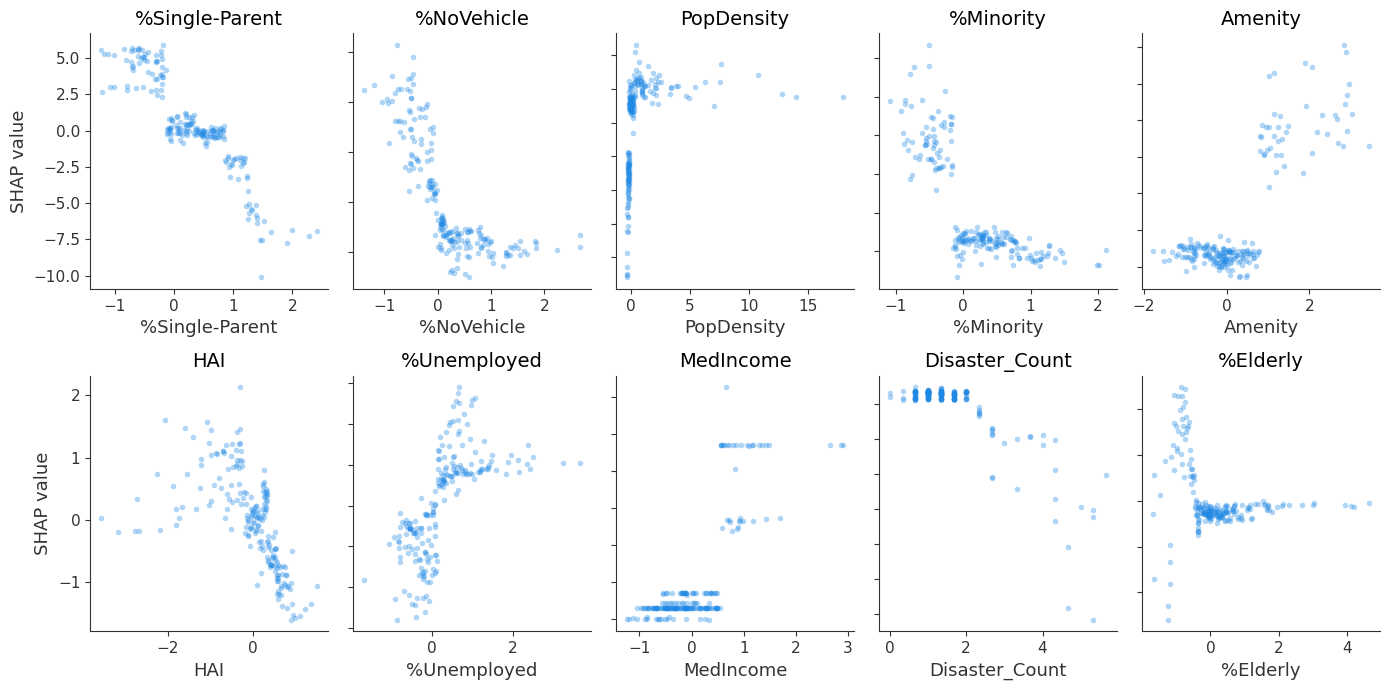

In [16]:
importance = np.abs(shap_values.values).mean(axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()

print("Top 10 important features:", top_features)

fig, axes = plt.subplots(2, 5, figsize=(14,7))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
    if i not in [0, 5]:  
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])
    else:
        axes[i].set_ylabel("SHAP value")
    axes[i].set_title(feature, fontsize=14)
# plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig(r"F:\LongMig2025\results\maps\automl\dependece_hurricane_high_0918.png", dpi=600, bbox_inches='tight')
plt.show()


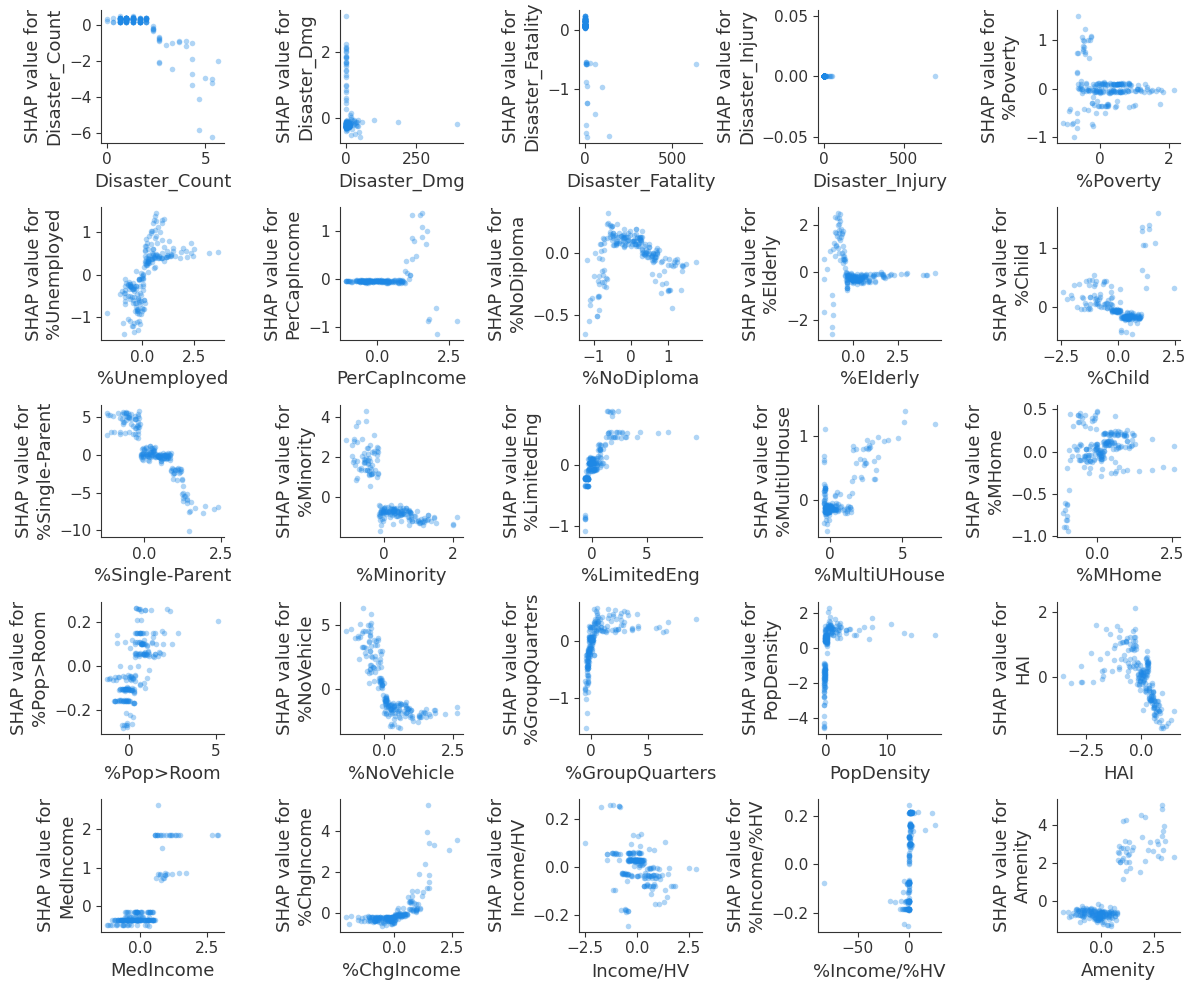

In [17]:
# Get all feature names
all_features = X.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Flood

## Without disaster variables

In [18]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Flood_Regression_data_high.csv")  # Adjust path if needed

In [19]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Disaster_Count","Disaster_Dmg","Disaster_Fatality","Disaster_Injury"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 15:28:58] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 15:28:58] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 15:28:58] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 15:28:58] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 15:28:58] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 15:28:58] {2393} INFO - Estimated sufficient time budget=3278s. Estimated necessary time budget=18s.
[flaml.automl.logger: 09-18 15:28:58] {2442} INFO -  at 0.4s,	estimator xgboost's best error=7.3605,	best estimator xgboost's best error=7.3605
[flaml.automl.logger: 09-18 15:28:58] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 15:28:58] {2442} INFO -  at 0.6s,	estimator lgbm's best error=7.3447,	best estimator lgbm's best error=7.3447
[flaml.automl.logger:

[flaml.automl.logger: 09-18 15:29:09] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 15:29:09] {2442} INFO -  at 11.6s,	estimator histgb's best error=5.4678,	best estimator histgb's best error=5.4678
[flaml.automl.logger: 09-18 15:29:09] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 09-18 15:29:10] {2442} INFO -  at 12.4s,	estimator extra_tree's best error=5.9934,	best estimator histgb's best error=5.4678
[flaml.automl.logger: 09-18 15:29:10] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 15:29:10] {2442} INFO -  at 12.6s,	estimator histgb's best error=5.3690,	best estimator histgb's best error=5.3690
[flaml.automl.logger: 09-18 15:29:10] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 15:29:11] {2442} INFO -  at 13.0s,	estimator histgb's best error=5.3690,	best estimator histgb's best error=5.3690
[flaml.automl.logger: 09-18 15:29:11] {2258} INFO - iteration 38

[flaml.automl.logger: 09-18 15:29:21] {2442} INFO -  at 23.6s,	estimator xgboost's best error=5.6156,	best estimator histgb's best error=5.2510
[flaml.automl.logger: 09-18 15:29:21] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 09-18 15:29:21] {2442} INFO -  at 23.7s,	estimator histgb's best error=5.2510,	best estimator histgb's best error=5.2510
[flaml.automl.logger: 09-18 15:29:21] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 15:29:22] {2442} INFO -  at 23.8s,	estimator histgb's best error=5.2510,	best estimator histgb's best error=5.2510
[flaml.automl.logger: 09-18 15:29:22] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 09-18 15:29:22] {2442} INFO -  at 24.0s,	estimator histgb's best error=5.2510,	best estimator histgb's best error=5.2510
[flaml.automl.logger: 09-18 15:29:22] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 09-18 15:29:22] {2442} INFO -  at 24.1s,	estimato

[flaml.automl.logger: 09-18 15:30:39] {2442} INFO -  at 101.6s,	estimator xgboost's best error=5.6156,	best estimator catboost's best error=5.1654
[flaml.automl.logger: 09-18 15:30:39] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 09-18 15:30:39] {2442} INFO -  at 101.7s,	estimator histgb's best error=5.2510,	best estimator catboost's best error=5.1654
[flaml.automl.logger: 09-18 15:30:39] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 09-18 15:30:40] {2442} INFO -  at 102.3s,	estimator extra_tree's best error=5.7562,	best estimator catboost's best error=5.1654
[flaml.automl.logger: 09-18 15:30:40] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 09-18 15:30:40] {2442} INFO -  at 102.5s,	estimator histgb's best error=5.2058,	best estimator catboost's best error=5.1654
[flaml.automl.logger: 09-18 15:30:40] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 09-18 15:30:40] {2442} IN

[flaml.automl.logger: 09-18 15:31:18] {2442} INFO -  at 140.7s,	estimator xgboost's best error=5.5842,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:31:18] {2258} INFO - iteration 140, current learner histgb
[flaml.automl.logger: 09-18 15:31:19] {2442} INFO -  at 141.1s,	estimator histgb's best error=5.1883,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:31:19] {2258} INFO - iteration 141, current learner extra_tree
[flaml.automl.logger: 09-18 15:31:20] {2442} INFO -  at 142.4s,	estimator extra_tree's best error=5.3790,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:31:20] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 09-18 15:31:20] {2442} INFO -  at 142.6s,	estimator histgb's best error=5.1883,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:31:20] {2258} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 09-18 15:31:21] {2442

[flaml.automl.logger: 09-18 15:32:14] {2258} INFO - iteration 174, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:32:15] {2442} INFO -  at 197.0s,	estimator xgb_limitdepth's best error=5.6515,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:32:15] {2258} INFO - iteration 175, current learner rf
[flaml.automl.logger: 09-18 15:32:15] {2442} INFO -  at 197.6s,	estimator rf's best error=5.5026,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:32:15] {2258} INFO - iteration 176, current learner rf
[flaml.automl.logger: 09-18 15:32:17] {2442} INFO -  at 199.5s,	estimator rf's best error=5.4634,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:32:17] {2258} INFO - iteration 177, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:32:18] {2442} INFO -  at 200.3s,	estimator xgb_limitdepth's best error=5.6515,	best estimator catboost's best error=5.1637
[flaml.automl.logger: 09-18 15:32:18] {2

[flaml.automl.logger: 09-18 15:33:42] {2442} INFO -  at 284.0s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1290
[flaml.automl.logger: 09-18 15:33:42] {2258} INFO - iteration 209, current learner catboost
[flaml.automl.logger: 09-18 15:33:49] {2442} INFO -  at 291.0s,	estimator catboost's best error=5.1290,	best estimator catboost's best error=5.1290
[flaml.automl.logger: 09-18 15:33:49] {2258} INFO - iteration 210, current learner lgbm
[flaml.automl.logger: 09-18 15:33:50] {2442} INFO -  at 292.3s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1290
[flaml.automl.logger: 09-18 15:33:50] {2258} INFO - iteration 211, current learner lgbm
[flaml.automl.logger: 09-18 15:33:53] {2442} INFO -  at 294.8s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1290
[flaml.automl.logger: 09-18 15:33:53] {2258} INFO - iteration 212, current learner lgbm
[flaml.automl.logger: 09-18 15:33:53] {2442} INFO -  at 295.3s,	

[flaml.automl.logger: 09-18 15:35:24] {2258} INFO - iteration 243, current learner xgboost
[flaml.automl.logger: 09-18 15:35:26] {2442} INFO -  at 388.7s,	estimator xgboost's best error=5.5352,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:35:26] {2258} INFO - iteration 244, current learner lgbm
[flaml.automl.logger: 09-18 15:35:27] {2442} INFO -  at 389.2s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:35:27] {2258} INFO - iteration 245, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:35:28] {2442} INFO -  at 390.3s,	estimator xgb_limitdepth's best error=5.3274,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:35:28] {2258} INFO - iteration 246, current learner histgb
[flaml.automl.logger: 09-18 15:35:28] {2442} INFO -  at 390.5s,	estimator histgb's best error=5.1883,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:35:28] {225

[flaml.automl.logger: 09-18 15:36:31] {2442} INFO -  at 452.8s,	estimator extra_tree's best error=5.2956,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:36:31] {2258} INFO - iteration 278, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:36:32] {2442} INFO -  at 454.6s,	estimator xgb_limitdepth's best error=5.3274,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:36:32] {2258} INFO - iteration 279, current learner lgbm
[flaml.automl.logger: 09-18 15:36:33] {2442} INFO -  at 455.1s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:36:33] {2258} INFO - iteration 280, current learner lgbm
[flaml.automl.logger: 09-18 15:36:35] {2442} INFO -  at 457.0s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:36:35] {2258} INFO - iteration 281, current learner catboost
[flaml.automl.logger: 09-18 15:36:46] {244

[flaml.automl.logger: 09-18 15:38:06] {2258} INFO - iteration 312, current learner lgbm
[flaml.automl.logger: 09-18 15:38:07] {2442} INFO -  at 549.1s,	estimator lgbm's best error=5.2499,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:38:07] {2258} INFO - iteration 313, current learner extra_tree
[flaml.automl.logger: 09-18 15:38:08] {2442} INFO -  at 550.6s,	estimator extra_tree's best error=5.2956,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:38:08] {2258} INFO - iteration 314, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:38:09] {2442} INFO -  at 551.6s,	estimator xgb_limitdepth's best error=5.2332,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:38:09] {2258} INFO - iteration 315, current learner lgbm
[flaml.automl.logger: 09-18 15:38:11] {2442} INFO -  at 553.1s,	estimator lgbm's best error=5.2432,	best estimator catboost's best error=5.1287
[flaml.automl.logger: 09-18 15:38:11] {2

In [20]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")


Best estimator: catboost
Best config: {'early_stopping_rounds': 17, 'learning_rate': 0.04768956138596522, 'n_estimators': 8192}
Best validation loss: 5.128743676674271
Best Model Performance:
RMSE = 4.0167, MAE = 3.0265, ME = -0.4792, R² = 0.6239


In [21]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
4,lgbm,3.693715,-0.329827,2.747318,0.681992
6,catboost,3.776503,-0.543148,2.958974,0.667577
2,rf,4.016542,-0.387828,3.000498,0.623975
1,xgb_limitdepth,4.079139,-0.350634,3.029238,0.612164
3,extra_tree,4.123300,-0.379492,2.979307,0.603721
0,xgboost,4.209352,-0.426409,3.234870,0.587008
5,histgb,4.610610,-0.819463,3.599201,0.504517


In [22]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
6,catboost,4.506209,0.653840,3.134073,0.201707,-0.116654,0.579272,0.649940,0.041631,4.544311,3.134334,-0.118106,0.649755
4,lgbm,4.820912,0.790370,3.357571,0.361878,-0.041690,0.510861,0.599118,0.068445,4.872815,3.357609,-0.042935,0.597287
1,xgb_limitdepth,4.822183,0.679594,3.358663,0.175481,-0.145325,0.543856,0.598838,0.045489,4.860700,3.358750,-0.146621,0.599287
3,extra_tree,4.899569,0.640087,3.315627,0.203119,-0.193848,0.567229,0.586910,0.020172,4.932837,3.315623,-0.195229,0.587305
0,xgboost,4.900903,0.705014,3.425741,0.137535,-0.187057,0.651412,0.585212,0.053621,4.941702,3.425821,-0.188677,0.585820
2,rf,4.946239,0.858556,3.319201,0.266986,-0.203885,0.622567,0.580248,0.058780,5.005771,3.319365,-0.205331,0.575011
5,histgb,4.949163,0.416737,3.561372,0.207200,-0.093793,0.801715,0.569755,0.080271,4.963573,3.561348,-0.095684,0.582146


## With disaster

In [23]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]
# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 15:40:37] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 15:40:37] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 15:40:37] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 15:40:37] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 15:40:37] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 15:40:37] {2393} INFO - Estimated sufficient time budget=3538s. Estimated necessary time budget=19s.
[flaml.automl.logger: 09-18 15:40:37] {2442} INFO -  at 0.4s,	estimator xgboost's best error=7.3605,	best estimator xgboost's best error=7.3605
[flaml.automl.logger: 09-18 15:40:37] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 15:40:37] {2442} INFO -  at 0.6s,	estimator lgbm's best error=7.3447,	best estimator lgbm's best error=7.3447
[flaml.automl.logger:

[flaml.automl.logger: 09-18 15:40:48] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 15:40:48] {2442} INFO -  at 11.7s,	estimator histgb's best error=5.4731,	best estimator histgb's best error=5.4731
[flaml.automl.logger: 09-18 15:40:48] {2258} INFO - iteration 35, current learner extra_tree
[flaml.automl.logger: 09-18 15:40:49] {2442} INFO -  at 12.5s,	estimator extra_tree's best error=5.8896,	best estimator histgb's best error=5.4731
[flaml.automl.logger: 09-18 15:40:49] {2258} INFO - iteration 36, current learner lgbm
[flaml.automl.logger: 09-18 15:40:50] {2442} INFO -  at 13.5s,	estimator lgbm's best error=5.5174,	best estimator histgb's best error=5.4731
[flaml.automl.logger: 09-18 15:40:50] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 15:40:50] {2442} INFO -  at 13.6s,	estimator histgb's best error=5.4731,	best estimator histgb's best error=5.4731
[flaml.automl.logger: 09-18 15:40:50] {2258} INFO - iteration 38, cu

[flaml.automl.logger: 09-18 15:41:19] {2258} INFO - iteration 70, current learner rf
[flaml.automl.logger: 09-18 15:41:20] {2442} INFO -  at 43.6s,	estimator rf's best error=5.8379,	best estimator catboost's best error=5.2816
[flaml.automl.logger: 09-18 15:41:20] {2258} INFO - iteration 71, current learner lgbm
[flaml.automl.logger: 09-18 15:41:21] {2442} INFO -  at 44.4s,	estimator lgbm's best error=5.3258,	best estimator catboost's best error=5.2816
[flaml.automl.logger: 09-18 15:41:21] {2258} INFO - iteration 72, current learner catboost
[flaml.automl.logger: 09-18 15:41:25] {2442} INFO -  at 49.0s,	estimator catboost's best error=5.2816,	best estimator catboost's best error=5.2816
[flaml.automl.logger: 09-18 15:41:25] {2258} INFO - iteration 73, current learner lgbm
[flaml.automl.logger: 09-18 15:41:27] {2442} INFO -  at 50.6s,	estimator lgbm's best error=5.3258,	best estimator catboost's best error=5.2816
[flaml.automl.logger: 09-18 15:41:27] {2258} INFO - iteration 74, current le

[flaml.automl.logger: 09-18 15:42:45] {2258} INFO - iteration 105, current learner xgboost
[flaml.automl.logger: 09-18 15:42:46] {2442} INFO -  at 129.3s,	estimator xgboost's best error=5.8642,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:42:46] {2258} INFO - iteration 106, current learner lgbm
[flaml.automl.logger: 09-18 15:42:47] {2442} INFO -  at 131.0s,	estimator lgbm's best error=5.3258,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:42:47] {2258} INFO - iteration 107, current learner rf
[flaml.automl.logger: 09-18 15:42:49] {2442} INFO -  at 132.8s,	estimator rf's best error=5.5695,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:42:49] {2258} INFO - iteration 108, current learner extra_tree
[flaml.automl.logger: 09-18 15:42:51] {2442} INFO -  at 134.0s,	estimator extra_tree's best error=5.7665,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:42:51] {2258} INFO - iterat

[flaml.automl.logger: 09-18 15:44:42] {2258} INFO - iteration 140, current learner xgboost
[flaml.automl.logger: 09-18 15:44:43] {2442} INFO -  at 246.3s,	estimator xgboost's best error=5.6524,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:44:43] {2258} INFO - iteration 141, current learner extra_tree
[flaml.automl.logger: 09-18 15:44:44] {2442} INFO -  at 247.3s,	estimator extra_tree's best error=5.4606,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:44:44] {2258} INFO - iteration 142, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 15:44:44] {2442} INFO -  at 247.9s,	estimator xgb_limitdepth's best error=5.7032,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:44:44] {2258} INFO - iteration 143, current learner lgbm
[flaml.automl.logger: 09-18 15:44:46] {2442} INFO -  at 249.2s,	estimator lgbm's best error=5.3040,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:44:

[flaml.automl.logger: 09-18 15:45:40] {2442} INFO -  at 303.0s,	estimator histgb's best error=5.3029,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:45:40] {2258} INFO - iteration 175, current learner histgb
[flaml.automl.logger: 09-18 15:45:40] {2442} INFO -  at 303.4s,	estimator histgb's best error=5.3029,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:45:40] {2258} INFO - iteration 176, current learner histgb
[flaml.automl.logger: 09-18 15:45:40] {2442} INFO -  at 303.5s,	estimator histgb's best error=5.3029,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:45:40] {2258} INFO - iteration 177, current learner histgb
[flaml.automl.logger: 09-18 15:45:40] {2442} INFO -  at 303.8s,	estimator histgb's best error=5.3029,	best estimator catboost's best error=5.2149
[flaml.automl.logger: 09-18 15:45:40] {2258} INFO - iteration 178, current learner catboost
[flaml.automl.logger: 09-18 15:45:56] {2442} INFO -  a

[flaml.automl.logger: 09-18 15:46:29] {2258} INFO - iteration 209, current learner histgb
[flaml.automl.logger: 09-18 15:46:29] {2442} INFO -  at 352.6s,	estimator histgb's best error=5.3029,	best estimator xgboost's best error=5.1793
[flaml.automl.logger: 09-18 15:46:29] {2258} INFO - iteration 210, current learner xgboost
[flaml.automl.logger: 09-18 15:46:33] {2442} INFO -  at 356.1s,	estimator xgboost's best error=5.1793,	best estimator xgboost's best error=5.1793
[flaml.automl.logger: 09-18 15:46:33] {2258} INFO - iteration 211, current learner xgboost
[flaml.automl.logger: 09-18 15:46:36] {2442} INFO -  at 359.7s,	estimator xgboost's best error=5.1685,	best estimator xgboost's best error=5.1685
[flaml.automl.logger: 09-18 15:46:36] {2258} INFO - iteration 212, current learner xgboost
[flaml.automl.logger: 09-18 15:46:41] {2442} INFO -  at 364.7s,	estimator xgboost's best error=5.1685,	best estimator xgboost's best error=5.1685
[flaml.automl.logger: 09-18 15:46:41] {2258} INFO - it

[flaml.automl.logger: 09-18 15:48:01] {2258} INFO - iteration 244, current learner lgbm
[flaml.automl.logger: 09-18 15:48:04] {2442} INFO -  at 447.4s,	estimator lgbm's best error=5.3040,	best estimator xgboost's best error=5.1464
[flaml.automl.logger: 09-18 15:48:04] {2258} INFO - iteration 245, current learner rf
[flaml.automl.logger: 09-18 15:48:05] {2442} INFO -  at 448.7s,	estimator rf's best error=5.5695,	best estimator xgboost's best error=5.1464
[flaml.automl.logger: 09-18 15:48:05] {2258} INFO - iteration 246, current learner histgb
[flaml.automl.logger: 09-18 15:48:06] {2442} INFO -  at 449.1s,	estimator histgb's best error=5.3029,	best estimator xgboost's best error=5.1464
[flaml.automl.logger: 09-18 15:48:06] {2258} INFO - iteration 247, current learner xgboost
[flaml.automl.logger: 09-18 15:48:14] {2442} INFO -  at 457.0s,	estimator xgboost's best error=5.1464,	best estimator xgboost's best error=5.1464
[flaml.automl.logger: 09-18 15:48:14] {2258} INFO - iteration 248, cur

[flaml.automl.logger: 09-18 15:49:21] {2258} INFO - iteration 279, current learner extra_tree
[flaml.automl.logger: 09-18 15:49:25] {2442} INFO -  at 528.8s,	estimator extra_tree's best error=5.3070,	best estimator xgboost's best error=5.1034
[flaml.automl.logger: 09-18 15:49:25] {2258} INFO - iteration 280, current learner rf
[flaml.automl.logger: 09-18 15:49:27] {2442} INFO -  at 530.3s,	estimator rf's best error=5.5695,	best estimator xgboost's best error=5.1034
[flaml.automl.logger: 09-18 15:49:27] {2258} INFO - iteration 281, current learner histgb
[flaml.automl.logger: 09-18 15:49:28] {2442} INFO -  at 531.4s,	estimator histgb's best error=5.2390,	best estimator xgboost's best error=5.1034
[flaml.automl.logger: 09-18 15:49:28] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 09-18 15:49:28] {2442} INFO -  at 531.8s,	estimator histgb's best error=5.2390,	best estimator xgboost's best error=5.1034
[flaml.automl.logger: 09-18 15:49:28] {2258} INFO - iteratio

In [24]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: xgboost
Best config: {'n_estimators': 183, 'max_leaves': 5, 'min_child_weight': 14.481037084837093, 'learning_rate': 0.1213227415543542, 'subsample': 0.7579760536308057, 'colsample_bylevel': 0.6331770948287919, 'colsample_bytree': 0.7516118400326078, 'reg_alpha': 0.025865229393909575, 'reg_lambda': 0.0009765625}
Best validation loss: 5.103391094760941
Best Model Performance:
RMSE = 3.8140, MAE = 2.8802, ME = -0.3443, R² = 0.6609


In [25]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
4,lgbm,3.640800,-0.349292,2.792794,0.691038
6,catboost,3.663903,-0.360763,2.882149,0.687104
0,xgboost,3.729455,-0.395571,2.884961,0.675808
3,extra_tree,3.798588,-0.328486,2.868795,0.663678
2,rf,3.804533,-0.209707,2.798779,0.662624
5,histgb,4.004770,-0.138429,3.096226,0.626176
1,xgb_limitdepth,4.511288,0.157559,3.357933,0.525635


In [26]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
6,catboost,4.584268,0.730526,3.173837,0.262799,-0.121373,0.561598,0.636581,0.067275,4.630971,3.174083,-0.122703,0.636269
5,histgb,4.721909,0.545764,3.310205,0.150589,-0.027506,0.622374,0.613784,0.043144,4.747255,3.310156,-0.029072,0.617773
4,lgbm,4.752911,0.731203,3.363898,0.330307,-0.075905,0.464432,0.610269,0.061511,4.797833,3.363825,-0.077065,0.609585
3,extra_tree,4.875654,0.837259,3.291503,0.275846,-0.187457,0.610097,0.592280,0.056713,4.932907,3.291470,-0.188918,0.587293
0,xgboost,4.953685,0.738855,3.366722,0.266094,0.137229,0.793707,0.575398,0.074341,4.997747,3.366697,0.135326,0.576372
2,rf,5.056308,0.833108,3.383004,0.307131,-0.199069,0.770799,0.559267,0.072941,5.111350,3.383127,-0.200764,0.556894
1,xgb_limitdepth,5.312730,0.847680,3.665498,0.326075,0.045873,0.494968,0.512385,0.084860,5.366990,3.665580,0.044768,0.511463


In [27]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: xgboost
R² Score: 0.6609
RMSE: 3.8140
MAE: 2.8802
ME (Mean Error): -0.3443


In [28]:
explainer = shap.Explainer(automl.model.predict, X)
shap_values = explainer(X)

shap_df_flood = pd.DataFrame(shap_values.values, columns=X.columns)
shap_df_flood["FIPS"] = fips_series.values

shap.summary_plot(shap_values, X,max_display=30,show=False)


fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Flood_all_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)

PermutationExplainer explainer: 680it [01:19,  7.52it/s]                                                               


In [29]:
shap.summary_plot(shap_values, X,max_display=20,show=False)

fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Flood_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)



Top 10 important features: ['Income/HV', 'PopDensity', '%NoVehicle', 'Amenity', '%ChgIncome', '%Minority', '%MHome', '%Elderly', 'PerCapIncome', '%Income/%HV']


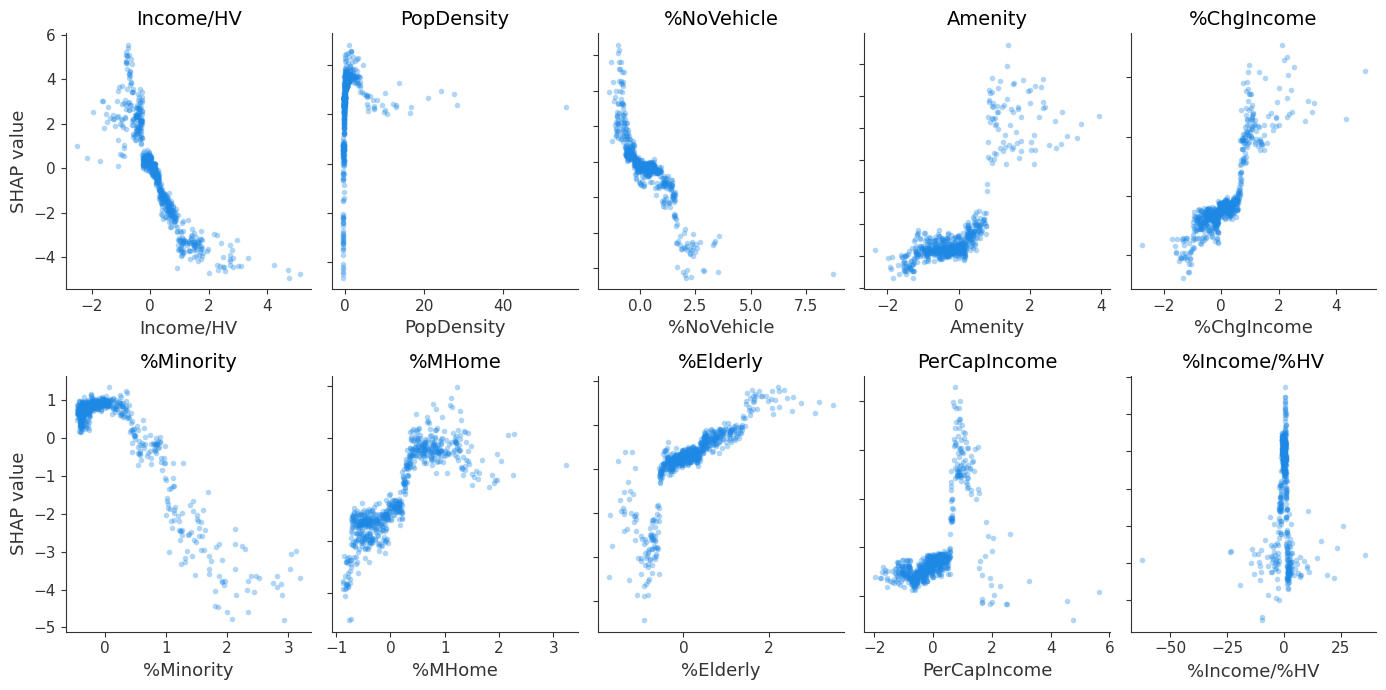

In [30]:
importance = np.abs(shap_values.values).mean(axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()

print("Top 10 important features:", top_features)

fig, axes = plt.subplots(2, 5, figsize=(14,7))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
    if i not in [0, 5]:  
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])
    else:
        axes[i].set_ylabel("SHAP value")
    axes[i].set_title(feature, fontsize=14)
# plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig(r"F:\LongMig2025\results\maps\automl\dependece_flood_high_0910.png", dpi=600, bbox_inches='tight')
plt.show()

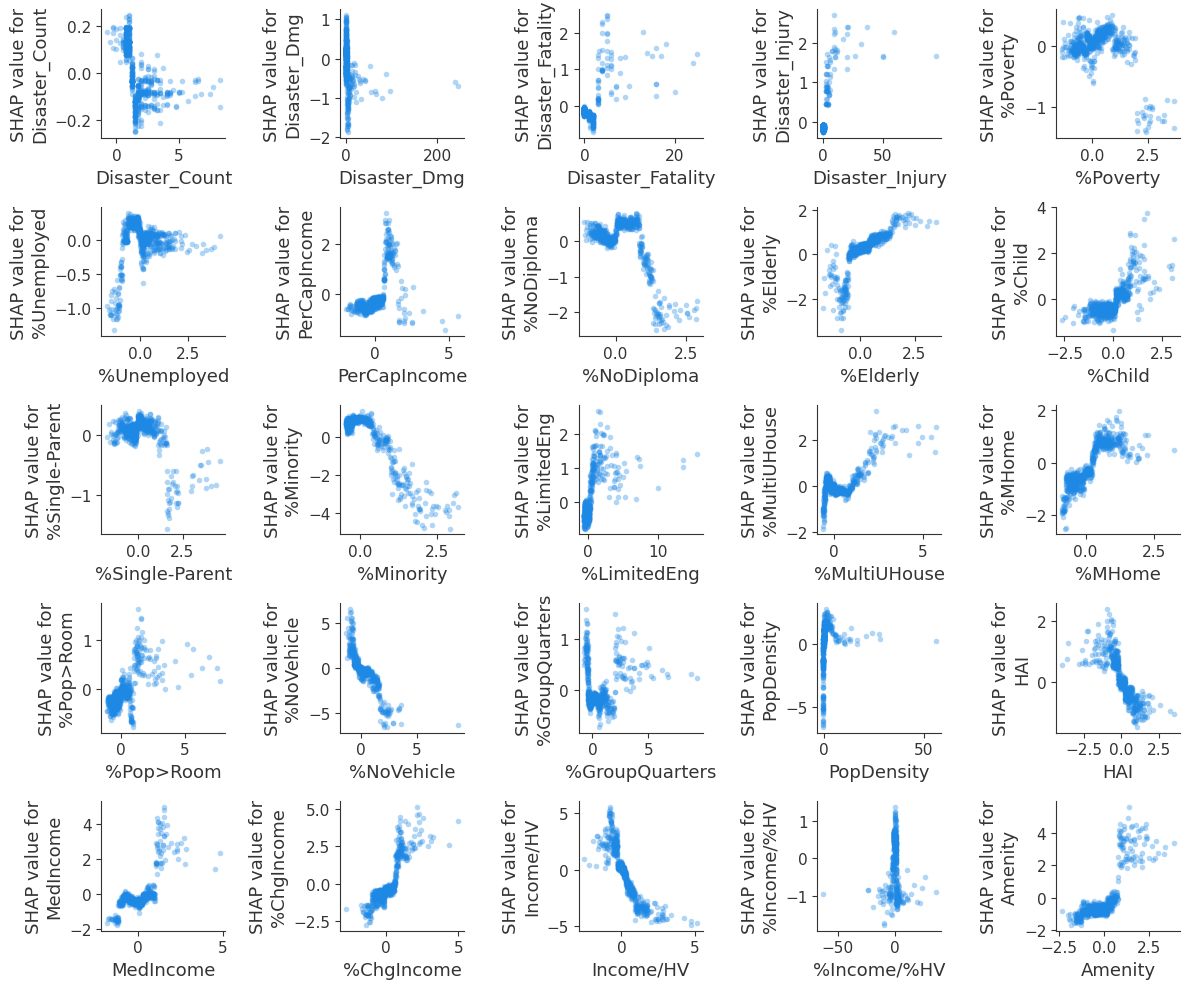

In [31]:
# Get all feature names
all_features = X.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Wildfire

## Without disaster

In [32]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Wildfire_Regression_data_high.csv")  # Adjust path if needed

In [33]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]

# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Disaster_Count","Disaster_Dmg","Disaster_Fatality","Disaster_Injury"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 15:53:47] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 15:53:47] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 15:53:47] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 15:53:47] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 15:53:47] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 15:53:48] {2393} INFO - Estimated sufficient time budget=3016s. Estimated necessary time budget=16s.
[flaml.automl.logger: 09-18 15:53:48] {2442} INFO -  at 0.3s,	estimator xgboost's best error=8.0083,	best estimator xgboost's best error=8.0083
[flaml.automl.logger: 09-18 15:53:48] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 15:53:48] {2442} INFO -  at 0.5s,	estimator lgbm's best error=8.0741,	best estimator xgboost's best error=8.0083
[flaml.automl.logg

[flaml.automl.logger: 09-18 15:53:56] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 15:53:56] {2442} INFO -  at 9.2s,	estimator histgb's best error=6.4081,	best estimator histgb's best error=6.4081
[flaml.automl.logger: 09-18 15:53:56] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 09-18 15:53:57] {2442} INFO -  at 9.7s,	estimator rf's best error=7.0251,	best estimator histgb's best error=6.4081
[flaml.automl.logger: 09-18 15:53:57] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 15:53:57] {2442} INFO -  at 10.0s,	estimator histgb's best error=6.4081,	best estimator histgb's best error=6.4081
[flaml.automl.logger: 09-18 15:53:57] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 15:53:57] {2442} INFO -  at 10.1s,	estimator histgb's best error=6.4081,	best estimator histgb's best error=6.4081
[flaml.automl.logger: 09-18 15:53:57] {2258} INFO - iteration 38, current learner 

[flaml.automl.logger: 09-18 15:54:04] {2442} INFO -  at 16.4s,	estimator xgboost's best error=6.4483,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:04] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 09-18 15:54:04] {2442} INFO -  at 16.5s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:04] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 15:54:04] {2442} INFO -  at 16.6s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:04] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 09-18 15:54:04] {2442} INFO -  at 16.6s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:04] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 09-18 15:54:04] {2442} INFO -  at 16.7s,	estimato

[flaml.automl.logger: 09-18 15:54:09] {2258} INFO - iteration 105, current learner catboost
[flaml.automl.logger: 09-18 15:54:12] {2442} INFO -  at 24.6s,	estimator catboost's best error=6.4646,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:12] {2258} INFO - iteration 106, current learner histgb
[flaml.automl.logger: 09-18 15:54:12] {2442} INFO -  at 24.7s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:12] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 09-18 15:54:12] {2442} INFO -  at 24.7s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:12] {2258} INFO - iteration 108, current learner catboost
[flaml.automl.logger: 09-18 15:54:14] {2442} INFO -  at 27.0s,	estimator catboost's best error=6.4646,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:14] {2258} INFO - iteratio

[flaml.automl.logger: 09-18 15:54:35] {2258} INFO - iteration 140, current learner histgb
[flaml.automl.logger: 09-18 15:54:35] {2442} INFO -  at 47.5s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:35] {2258} INFO - iteration 141, current learner extra_tree
[flaml.automl.logger: 09-18 15:54:36] {2442} INFO -  at 48.4s,	estimator extra_tree's best error=6.2983,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:36] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 09-18 15:54:36] {2442} INFO -  at 48.5s,	estimator histgb's best error=6.1214,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:36] {2258} INFO - iteration 143, current learner extra_tree
[flaml.automl.logger: 09-18 15:54:37] {2442} INFO -  at 49.4s,	estimator extra_tree's best error=6.2983,	best estimator histgb's best error=6.1214
[flaml.automl.logger: 09-18 15:54:37] {2258} INFO - 

...

[flaml.automl.logger: 09-18 16:02:00] {2258} INFO - iteration 564, current learner lgbm
[flaml.automl.logger: 09-18 16:02:01] {2442} INFO -  at 493.5s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:01] {2258} INFO - iteration 565, current learner lgbm
[flaml.automl.logger: 09-18 16:02:01] {2442} INFO -  at 494.0s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:01] {2258} INFO - iteration 566, current learner xgboost
[flaml.automl.logger: 09-18 16:02:02] {2442} INFO -  at 494.3s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:02] {2258} INFO - iteration 567, current learner xgboost
[flaml.automl.logger: 09-18 16:02:02] {2442} INFO -  at 494.7s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:02] {2258} INFO - iteration 568, current l

[flaml.automl.logger: 09-18 16:02:24] {2442} INFO -  at 516.6s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:24] {2258} INFO - iteration 600, current learner xgboost
[flaml.automl.logger: 09-18 16:02:24] {2442} INFO -  at 517.1s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:24] {2258} INFO - iteration 601, current learner xgboost
[flaml.automl.logger: 09-18 16:02:25] {2442} INFO -  at 517.5s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:25] {2258} INFO - iteration 602, current learner xgboost
[flaml.automl.logger: 09-18 16:02:25] {2442} INFO -  at 517.9s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:25] {2258} INFO - iteration 603, current learner xgboost
[flaml.automl.logger: 09-18 16:02:25] {2442} INFO -  at 518.2s,	est

[flaml.automl.logger: 09-18 16:02:43] {2442} INFO -  at 535.3s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:43] {2258} INFO - iteration 635, current learner lgbm
[flaml.automl.logger: 09-18 16:02:43] {2442} INFO -  at 536.2s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:43] {2258} INFO - iteration 636, current learner lgbm
[flaml.automl.logger: 09-18 16:02:44] {2442} INFO -  at 536.7s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:44] {2258} INFO - iteration 637, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:02:45] {2442} INFO -  at 537.4s,	estimator xgb_limitdepth's best error=5.9185,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:02:45] {2258} INFO - iteration 638, current learner lgbm
[flaml.automl.logger: 09-18 16:02:46] {2442} INFO -  at 538.6s,	esti

[flaml.automl.logger: 09-18 16:03:03] {2258} INFO - iteration 670, current learner lgbm
[flaml.automl.logger: 09-18 16:03:03] {2442} INFO -  at 556.2s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:03] {2258} INFO - iteration 671, current learner xgboost
[flaml.automl.logger: 09-18 16:03:04] {2442} INFO -  at 556.5s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:04] {2258} INFO - iteration 672, current learner lgbm
[flaml.automl.logger: 09-18 16:03:04] {2442} INFO -  at 557.3s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:04] {2258} INFO - iteration 673, current learner lgbm
[flaml.automl.logger: 09-18 16:03:06] {2442} INFO -  at 558.4s,	estimator lgbm's best error=5.7632,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:06] {2258} INFO - iteration 674, current learner

[flaml.automl.logger: 09-18 16:03:24] {2442} INFO -  at 577.1s,	estimator xgb_limitdepth's best error=5.7684,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:24] {2258} INFO - iteration 706, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:03:25] {2442} INFO -  at 578.2s,	estimator xgb_limitdepth's best error=5.7684,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:25] {2258} INFO - iteration 707, current learner xgboost
[flaml.automl.logger: 09-18 16:03:26] {2442} INFO -  at 578.6s,	estimator xgboost's best error=6.0521,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:26] {2258} INFO - iteration 708, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:03:27] {2442} INFO -  at 579.3s,	estimator xgb_limitdepth's best error=5.7684,	best estimator lgbm's best error=5.7632
[flaml.automl.logger: 09-18 16:03:27] {2258} INFO - iteration 709, current learner xgb_limitdepth
[flaml.automl.logger: 

In [34]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: xgb_limitdepth
Best config: {'n_estimators': 21, 'max_depth': 5, 'min_child_weight': 0.07210753628301798, 'learning_rate': 1.0, 'subsample': 0.7280568339268091, 'colsample_bylevel': 0.9442765896995934, 'colsample_bytree': 0.9770064894146301, 'reg_alpha': 0.08806043400303694, 'reg_lambda': 66.6737802885616}
Best validation loss: 5.65391795685526
Best Model Performance:
RMSE = 6.2935, MAE = 4.7987, ME = 1.1869, R² = 0.4627


In [35]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
6,catboost,6.034024,1.930867,4.115666,0.506069
4,lgbm,6.108270,1.930266,4.496633,0.493839
1,xgb_limitdepth,6.396536,1.221670,4.879969,0.444937
5,histgb,6.397233,1.920622,4.466791,0.444816
0,xgboost,6.433660,2.223915,4.604189,0.438476
3,extra_tree,6.587662,1.783151,4.360750,0.411272
2,rf,6.933360,1.321175,5.362932,0.347861


In [36]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
1,xgb_limitdepth,5.714678,0.781528,4.484708,0.660379,-0.038726,1.631123,0.552009,0.097903,5.759162,4.485691,-0.025467,0.563489
6,catboost,5.784200,0.670327,4.260482,0.529675,-0.163210,1.622281,0.544030,0.061571,5.822366,4.265405,-0.152253,0.553856
4,lgbm,5.853660,0.730900,4.549334,0.665234,-0.167533,1.561606,0.524745,0.125063,5.896383,4.553861,-0.157702,0.542440
5,histgb,6.063927,0.246759,4.661728,0.281995,-0.102007,1.813628,0.490870,0.090820,6.070570,4.663373,-0.092339,0.515007
3,extra_tree,6.219818,0.557096,4.429077,0.406250,-0.187299,1.927173,0.469548,0.081432,6.244905,4.432756,-0.175878,0.486751
2,rf,6.418441,0.530062,4.970553,0.575527,0.202366,1.612468,0.428555,0.134725,6.436688,4.969919,0.209561,0.454743
0,xgboost,6.475456,1.171496,5.131099,0.798185,0.139286,1.801870,0.429272,0.132763,6.567918,5.138953,0.149662,0.432283


## With disaster

In [37]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]

# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 16:04:40] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 16:04:40] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 16:04:40] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 16:04:40] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 16:04:40] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 16:04:40] {2393} INFO - Estimated sufficient time budget=3230s. Estimated necessary time budget=17s.
[flaml.automl.logger: 09-18 16:04:40] {2442} INFO -  at 0.4s,	estimator xgboost's best error=8.0083,	best estimator xgboost's best error=8.0083
[flaml.automl.logger: 09-18 16:04:40] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 16:04:40] {2442} INFO -  at 0.5s,	estimator lgbm's best error=8.0741,	best estimator xgboost's best error=8.0083
[flaml.automl.logg

[flaml.automl.logger: 09-18 16:04:49] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 16:04:49] {2442} INFO -  at 9.2s,	estimator histgb's best error=6.3452,	best estimator histgb's best error=6.3452
[flaml.automl.logger: 09-18 16:04:49] {2258} INFO - iteration 35, current learner histgb
[flaml.automl.logger: 09-18 16:04:49] {2442} INFO -  at 9.3s,	estimator histgb's best error=6.3452,	best estimator histgb's best error=6.3452
[flaml.automl.logger: 09-18 16:04:49] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 16:04:49] {2442} INFO -  at 9.4s,	estimator histgb's best error=6.3452,	best estimator histgb's best error=6.3452
[flaml.automl.logger: 09-18 16:04:49] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 16:04:49] {2442} INFO -  at 9.4s,	estimator histgb's best error=6.3452,	best estimator histgb's best error=6.3452
[flaml.automl.logger: 09-18 16:04:49] {2258} INFO - iteration 38, current le

[flaml.automl.logger: 09-18 16:04:56] {2442} INFO -  at 16.0s,	estimator xgboost's best error=6.6614,	best estimator histgb's best error=6.0319
[flaml.automl.logger: 09-18 16:04:56] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 09-18 16:04:56] {2442} INFO -  at 16.0s,	estimator histgb's best error=6.0319,	best estimator histgb's best error=6.0319
[flaml.automl.logger: 09-18 16:04:56] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 16:04:56] {2442} INFO -  at 16.1s,	estimator histgb's best error=6.0319,	best estimator histgb's best error=6.0319
[flaml.automl.logger: 09-18 16:04:56] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 09-18 16:04:56] {2442} INFO -  at 16.2s,	estimator histgb's best error=6.0319,	best estimator histgb's best error=6.0319
[flaml.automl.logger: 09-18 16:04:56] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 09-18 16:04:56] {2442} INFO -  at 16.3s,	estimato

[flaml.automl.logger: 09-18 16:05:01] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 09-18 16:05:02] {2442} INFO -  at 22.0s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:02] {2258} INFO - iteration 106, current learner histgb
[flaml.automl.logger: 09-18 16:05:02] {2442} INFO -  at 22.1s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:02] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 09-18 16:05:02] {2442} INFO -  at 22.2s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:02] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 09-18 16:05:02] {2442} INFO -  at 22.4s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:02] {2258} INFO - iteration 109, c

[flaml.automl.logger: 09-18 16:05:10] {2442} INFO -  at 30.6s,	estimator extra_tree's best error=6.9068,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:10] {2258} INFO - iteration 141, current learner histgb
[flaml.automl.logger: 09-18 16:05:10] {2442} INFO -  at 30.7s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:10] {2258} INFO - iteration 142, current learner catboost
[flaml.automl.logger: 09-18 16:05:13] {2442} INFO -  at 33.4s,	estimator catboost's best error=6.8455,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:13] {2258} INFO - iteration 143, current learner histgb
[flaml.automl.logger: 09-18 16:05:13] {2442} INFO -  at 33.5s,	estimator histgb's best error=5.9510,	best estimator histgb's best error=5.9510
[flaml.automl.logger: 09-18 16:05:13] {2258} INFO - iteration 144, current learner catboost
[flaml.automl.logger: 09-18 16:05:16] {2442} INFO -  at 36

...

[flaml.automl.logger: 09-18 16:11:26] {2442} INFO -  at 406.7s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:11:26] {2258} INFO - iteration 764, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:11:28] {2442} INFO -  at 408.0s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:11:28] {2258} INFO - iteration 765, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:11:29] {2442} INFO -  at 409.2s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:11:29] {2258} INFO - iteration 766, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:11:29] {2442} INFO -  at 409.9s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:11:29] {2258} INFO - iteration 767,

[flaml.automl.logger: 09-18 16:12:19] {2442} INFO -  at 459.6s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:12:19] {2258} INFO - iteration 796, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:12:21] {2442} INFO -  at 461.1s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:12:21] {2258} INFO - iteration 797, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:12:22] {2442} INFO -  at 462.3s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:12:22] {2258} INFO - iteration 798, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:12:23] {2442} INFO -  at 463.5s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:12:23] {2258} INFO - iteration 799,

[flaml.automl.logger: 09-18 16:13:03] {2258} INFO - iteration 828, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:13:04] {2442} INFO -  at 504.5s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:04] {2258} INFO - iteration 829, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:13:06] {2442} INFO -  at 506.1s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:06] {2258} INFO - iteration 830, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:13:07] {2442} INFO -  at 507.1s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:07] {2258} INFO - iteration 831, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:13:08] {2442} INFO -  at 508.5s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb

[flaml.automl.logger: 09-18 16:13:41] {2442} INFO -  at 541.1s,	estimator xgboost's best error=6.0784,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:41] {2258} INFO - iteration 861, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:13:42] {2442} INFO -  at 542.7s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:42] {2258} INFO - iteration 862, current learner catboost
[flaml.automl.logger: 09-18 16:13:47] {2442} INFO -  at 547.3s,	estimator catboost's best error=6.4679,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:47] {2258} INFO - iteration 863, current learner catboost
[flaml.automl.logger: 09-18 16:13:55] {2442} INFO -  at 555.1s,	estimator catboost's best error=6.4679,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:13:55] {2258} INFO - iteration 864, current learner xgb_limitdepth

[flaml.automl.logger: 09-18 16:14:26] {2258} INFO - iteration 894, current learner xgboost
[flaml.automl.logger: 09-18 16:14:27] {2442} INFO -  at 587.0s,	estimator xgboost's best error=5.7265,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:14:27] {2258} INFO - iteration 895, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:14:27] {2442} INFO -  at 587.9s,	estimator xgb_limitdepth's best error=5.5501,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:14:27] {2258} INFO - iteration 896, current learner xgboost
[flaml.automl.logger: 09-18 16:14:28] {2442} INFO -  at 588.7s,	estimator xgboost's best error=5.7265,	best estimator xgb_limitdepth's best error=5.5501
[flaml.automl.logger: 09-18 16:14:28] {2258} INFO - iteration 897, current learner xgboost
[flaml.automl.logger: 09-18 16:14:29] {2442} INFO -  at 589.8s,	estimator xgboost's best error=5.7265,	best estimator xgb_limitdepth's best error=5.5501
[flaml.aut

In [38]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: xgb_limitdepth
Best config: {'n_estimators': 31, 'max_depth': 5, 'min_child_weight': 15.626850523403379, 'learning_rate': 1.0, 'subsample': 0.7485646363135146, 'colsample_bylevel': 0.5902653848698026, 'colsample_bytree': 0.8635974280205373, 'reg_alpha': 1.8273142133225075, 'reg_lambda': 28.63186194272393}
Best validation loss: 5.550074521154969
Best Model Performance:
RMSE = 5.8973, MAE = 4.8933, ME = 1.2366, R² = 0.5282


In [39]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
4,lgbm,5.897483,1.823725,4.400681,0.528170
5,histgb,5.946402,1.776910,4.255345,0.520310
6,catboost,6.011676,1.782658,4.131155,0.509721
3,extra_tree,6.822748,0.730713,4.753115,0.368503
1,xgb_limitdepth,7.113966,1.924332,5.604174,0.313444
2,rf,7.269481,2.363825,5.121928,0.283099
0,xgboost,8.827978,1.926469,6.085068,-0.057243


In [40]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
5,histgb,5.378393,0.696209,4.088037,0.453528,0.069715,1.380989,0.598286,0.106907,5.421976,4.092924,0.080270,0.613106
6,catboost,5.656645,0.677929,4.200070,0.536650,-0.080083,1.437575,0.564078,0.060414,5.696781,4.205479,-0.070255,0.572894
4,lgbm,5.698722,0.433257,4.391720,0.380328,0.112344,1.535498,0.556003,0.045113,5.716298,4.395798,0.117916,0.569963
2,rf,6.309575,0.591902,4.833454,0.404650,-0.320256,1.936831,0.447590,0.125112,6.338545,4.838059,-0.308519,0.471244
1,xgb_limitdepth,6.353867,1.162102,4.958278,0.760314,0.018600,1.548202,0.447456,0.143809,6.442819,4.963858,0.028406,0.453704
3,extra_tree,6.529523,0.538965,4.902751,0.357753,-0.565319,1.455852,0.418442,0.047632,6.552761,4.905706,-0.559106,0.434900
0,xgboost,7.593109,1.008740,5.588670,0.504574,-0.496805,1.929849,0.192265,0.253766,7.652026,5.588171,-0.489045,0.229399


In [41]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: xgb_limitdepth
R² Score: 0.5282
RMSE: 5.8973
MAE: 4.8933
ME (Mean Error): 1.2366


In [42]:
explainer = shap.Explainer(automl.model.predict, X)
shap_values = explainer(X)

shap_df_wildfire = pd.DataFrame(shap_values.values, columns=X.columns)
shap_df_wildfire["FIPS"] = fips_series.values

shap.summary_plot(shap_values, X,max_display=30,show=False)

fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Wildfire_all_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)



PermutationExplainer explainer: 138it [00:14,  2.96it/s]                                                               


In [43]:
shap.summary_plot(shap_values, X,max_display=20,show=False)

fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Wildfire_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)

Top 10 important features: ['PopDensity', 'Income/HV', '%ChgIncome', '%LimitedEng', '%MHome', '%NoVehicle', 'Disaster_Injury', '%NoDiploma', 'PerCapIncome', 'MedIncome']


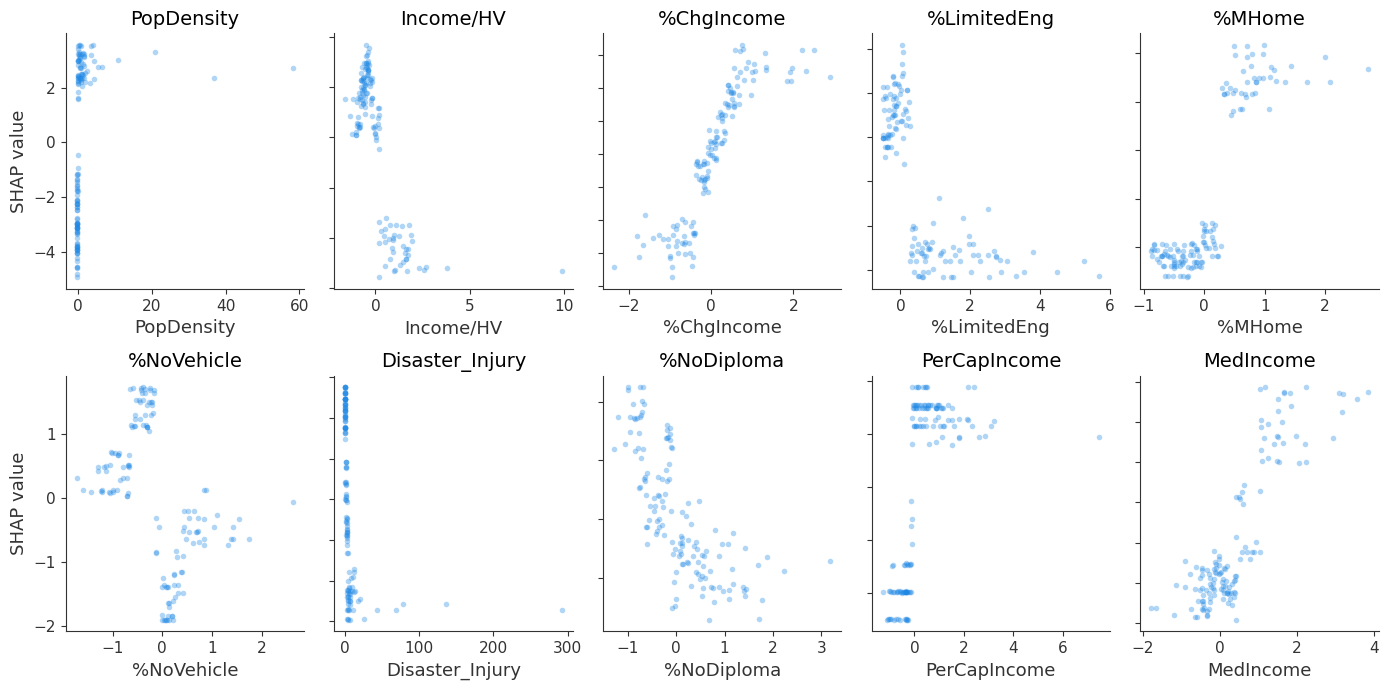

In [44]:
importance = np.abs(shap_values.values).mean(axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()

print("Top 10 important features:", top_features)

fig, axes = plt.subplots(2, 5, figsize=(14,7))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
    if i not in [0, 5]:  
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])
    else:
        axes[i].set_ylabel("SHAP value")
    axes[i].set_title(feature, fontsize=14)
# plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig(r"F:\LongMig2025\results\maps\automl\dependece_wildfire_high_0918.png", dpi=600, bbox_inches='tight')
plt.show()

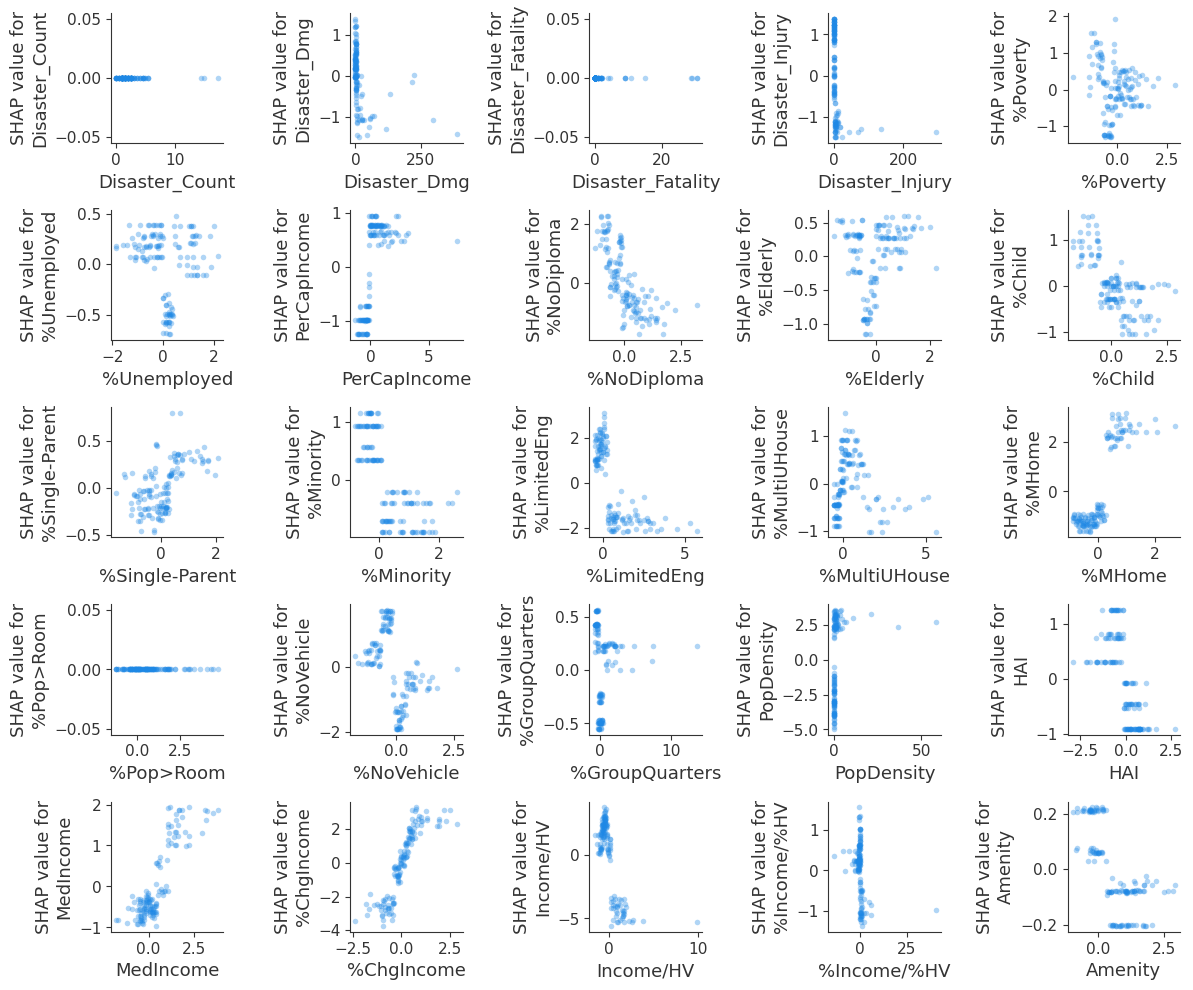

In [45]:
# Get all feature names
all_features = X.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

## Tornado

## Without disaster

In [46]:
# Load your hurricane regression data
data_path = "F:/LongMig2025/data/"
df = pd.read_csv(data_path+"Regression/Tornado_Regression_data_high.csv")  # Adjust path if needed

In [47]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]


# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR","Disaster_Count","Disaster_Dmg","Disaster_Fatality","Disaster_Injury"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 16:15:55] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 16:15:55] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 16:15:55] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 16:15:55] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 16:15:55] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 16:15:55] {2393} INFO - Estimated sufficient time budget=3027s. Estimated necessary time budget=16s.
[flaml.automl.logger: 09-18 16:15:55] {2442} INFO -  at 0.3s,	estimator xgboost's best error=7.2048,	best estimator xgboost's best error=7.2048
[flaml.automl.logger: 09-18 16:15:55] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 16:15:55] {2442} INFO -  at 0.5s,	estimator lgbm's best error=7.2275,	best estimator xgboost's best error=7.2048
[flaml.automl.logg

[flaml.automl.logger: 09-18 16:16:07] {2442} INFO -  at 12.5s,	estimator extra_tree's best error=5.2510,	best estimator histgb's best error=4.8188
[flaml.automl.logger: 09-18 16:16:07] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 16:16:07] {2442} INFO -  at 12.7s,	estimator histgb's best error=4.7370,	best estimator histgb's best error=4.7370
[flaml.automl.logger: 09-18 16:16:07] {2258} INFO - iteration 35, current learner xgboost
[flaml.automl.logger: 09-18 16:16:08] {2442} INFO -  at 13.2s,	estimator xgboost's best error=5.2781,	best estimator histgb's best error=4.7370
[flaml.automl.logger: 09-18 16:16:08] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 16:16:08] {2442} INFO -  at 13.6s,	estimator histgb's best error=4.7370,	best estimator histgb's best error=4.7370
[flaml.automl.logger: 09-18 16:16:08] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 16:16:08] {2442} INFO -  at 13.7s,	est

[flaml.automl.logger: 09-18 16:16:18] {2258} INFO - iteration 69, current learner extra_tree
[flaml.automl.logger: 09-18 16:16:19] {2442} INFO -  at 24.6s,	estimator extra_tree's best error=4.8617,	best estimator histgb's best error=4.5238
[flaml.automl.logger: 09-18 16:16:19] {2258} INFO - iteration 70, current learner histgb
[flaml.automl.logger: 09-18 16:16:20] {2442} INFO -  at 25.0s,	estimator histgb's best error=4.5185,	best estimator histgb's best error=4.5185
[flaml.automl.logger: 09-18 16:16:20] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 16:16:20] {2442} INFO -  at 25.1s,	estimator histgb's best error=4.5185,	best estimator histgb's best error=4.5185
[flaml.automl.logger: 09-18 16:16:20] {2258} INFO - iteration 72, current learner histgb
[flaml.automl.logger: 09-18 16:16:20] {2442} INFO -  at 25.9s,	estimator histgb's best error=4.4521,	best estimator histgb's best error=4.4521
[flaml.automl.logger: 09-18 16:16:20] {2258} INFO - iteration 73

[flaml.automl.logger: 09-18 16:16:52] {2442} INFO -  at 57.3s,	estimator rf's best error=5.1638,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:16:52] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 09-18 16:16:53] {2442} INFO -  at 58.0s,	estimator histgb's best error=4.4188,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:16:53] {2258} INFO - iteration 106, current learner extra_tree
[flaml.automl.logger: 09-18 16:16:53] {2442} INFO -  at 58.9s,	estimator extra_tree's best error=4.6450,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:16:53] {2258} INFO - iteration 107, current learner lgbm
[flaml.automl.logger: 09-18 16:16:54] {2442} INFO -  at 59.5s,	estimator lgbm's best error=4.6560,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:16:54] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 09-18 16:16:55] {2442} INFO -  at 60.6s,	estim

[flaml.automl.logger: 09-18 16:17:23] {2258} INFO - iteration 139, current learner lgbm
[flaml.automl.logger: 09-18 16:17:24] {2442} INFO -  at 89.5s,	estimator lgbm's best error=4.6261,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:17:24] {2258} INFO - iteration 140, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:17:25] {2442} INFO -  at 90.0s,	estimator xgb_limitdepth's best error=4.8313,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:17:25] {2258} INFO - iteration 141, current learner histgb
[flaml.automl.logger: 09-18 16:17:25] {2442} INFO -  at 90.2s,	estimator histgb's best error=4.4188,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:17:25] {2258} INFO - iteration 142, current learner extra_tree
[flaml.automl.logger: 09-18 16:17:26] {2442} INFO -  at 91.0s,	estimator extra_tree's best error=4.6450,	best estimator histgb's best error=4.4188
[flaml.automl.logger: 09-18 16:17:26] {2258} INF

...

[flaml.automl.logger: 09-18 16:20:40] {2442} INFO -  at 285.9s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:20:40] {2258} INFO - iteration 279, current learner histgb
[flaml.automl.logger: 09-18 16:20:44] {2442} INFO -  at 289.6s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:20:44] {2258} INFO - iteration 280, current learner histgb
[flaml.automl.logger: 09-18 16:20:46] {2442} INFO -  at 291.4s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:20:46] {2258} INFO - iteration 281, current learner histgb
[flaml.automl.logger: 09-18 16:20:47] {2442} INFO -  at 292.7s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:20:47] {2258} INFO - iteration 282, current learner histgb
[flaml.automl.logger: 09-18 16:20:48] {2442} INFO -  at 293.8s,	

[flaml.automl.logger: 09-18 16:21:36] {2258} INFO - iteration 313, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:21:39] {2442} INFO -  at 344.5s,	estimator xgb_limitdepth's best error=4.4031,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:21:39] {2258} INFO - iteration 314, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:21:42] {2442} INFO -  at 347.8s,	estimator xgb_limitdepth's best error=4.4031,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:21:42] {2258} INFO - iteration 315, current learner histgb
[flaml.automl.logger: 09-18 16:21:44] {2442} INFO -  at 349.3s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:21:44] {2258} INFO - iteration 316, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:21:45] {2442} INFO -  at 350.4s,	estimator xgb_limitdepth's best error=4.4031,	best estimator histgb's best error=4.3949
[flaml.automl.lo

[flaml.automl.logger: 09-18 16:22:37] {2442} INFO -  at 402.5s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:22:37] {2258} INFO - iteration 348, current learner catboost
[flaml.automl.logger: 09-18 16:22:42] {2442} INFO -  at 407.1s,	estimator catboost's best error=4.6647,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:22:42] {2258} INFO - iteration 349, current learner histgb
[flaml.automl.logger: 09-18 16:22:43] {2442} INFO -  at 408.9s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:22:43] {2258} INFO - iteration 350, current learner histgb
[flaml.automl.logger: 09-18 16:22:46] {2442} INFO -  at 411.0s,	estimator histgb's best error=4.3949,	best estimator histgb's best error=4.3949
[flaml.automl.logger: 09-18 16:22:46] {2258} INFO - iteration 351, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:22:48] {2442} INFO - 

[flaml.automl.logger: 09-18 16:23:43] {2258} INFO - iteration 382, current learner lgbm
[flaml.automl.logger: 09-18 16:23:49] {2442} INFO -  at 474.7s,	estimator lgbm's best error=4.4862,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:23:49] {2258} INFO - iteration 383, current learner catboost
[flaml.automl.logger: 09-18 16:23:51] {2442} INFO -  at 476.8s,	estimator catboost's best error=4.5383,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:23:51] {2258} INFO - iteration 384, current learner histgb
[flaml.automl.logger: 09-18 16:23:53] {2442} INFO -  at 478.2s,	estimator histgb's best error=4.3893,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:23:53] {2258} INFO - iteration 385, current learner histgb
[flaml.automl.logger: 09-18 16:23:55] {2442} INFO -  at 480.1s,	estimator histgb's best error=4.3893,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:23:55] {2258} INFO - iteration 38

[flaml.automl.logger: 09-18 16:25:06] {2258} INFO - iteration 417, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:25:08] {2442} INFO -  at 553.7s,	estimator xgb_limitdepth's best error=4.4031,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:25:08] {2258} INFO - iteration 418, current learner histgb
[flaml.automl.logger: 09-18 16:25:10] {2442} INFO -  at 555.3s,	estimator histgb's best error=4.3893,	best estimator histgb's best error=4.3893
[flaml.automl.logger: 09-18 16:25:10] {2258} INFO - iteration 419, current learner histgb
[flaml.automl.logger: 09-18 16:25:11] {2442} INFO -  at 556.2s,	estimator histgb's best error=4.3692,	best estimator histgb's best error=4.3692
[flaml.automl.logger: 09-18 16:25:11] {2258} INFO - iteration 420, current learner histgb
[flaml.automl.logger: 09-18 16:25:13] {2442} INFO -  at 558.0s,	estimator histgb's best error=4.3692,	best estimator histgb's best error=4.3692
[flaml.automl.logger: 09-18 16:25:13] {2258} INF

In [48]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: histgb
Best config: {'n_estimators': 199, 'max_leaves': 11, 'min_samples_leaf': 2, 'learning_rate': 0.03524172644743649, 'log_max_bin': 7, 'l2_regularization': 0.03238909618878717, 'max_iter': 199}
Best validation loss: 4.369179243569889
Best Model Performance:
RMSE = 4.2855, MAE = 3.0412, ME = -0.1834, R² = 0.7334


In [49]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
5,histgb,4.371871,-0.539836,3.020543,0.722522
1,xgb_limitdepth,4.381371,-0.003603,3.021163,0.721315
2,rf,4.455576,-0.312287,3.023692,0.711795
4,lgbm,4.636197,-0.083231,3.274700,0.687955
6,catboost,4.712660,-0.178134,3.373819,0.677577
3,extra_tree,4.721515,-0.220446,3.181897,0.676364
0,xgboost,4.933276,-0.228049,3.533046,0.646683


In [50]:


def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
6,catboost,4.387144,0.287888,3.158808,0.136422,-0.003174,0.478540,0.712717,0.024925,4.395158,3.158988,-0.003445,0.717508
4,lgbm,4.427320,0.412964,3.176360,0.171672,-0.003738,0.608199,0.708898,0.017129,4.443050,3.176534,-0.003879,0.711318
1,xgb_limitdepth,4.491955,0.561194,3.241427,0.387501,-0.047128,0.533152,0.698434,0.055843,4.519672,3.241038,-0.047051,0.701275
5,histgb,4.547838,0.393951,3.234246,0.244449,-0.209842,0.585659,0.690821,0.041416,4.561140,3.233869,-0.210425,0.695768
2,rf,4.578755,0.386008,3.274734,0.270237,-0.112112,0.479501,0.687889,0.026396,4.591575,3.274311,-0.112433,0.691695
3,extra_tree,4.872415,0.413521,3.491907,0.269857,-0.110989,0.232742,0.646171,0.036355,4.886159,3.491399,-0.111197,0.650866
0,xgboost,5.082202,0.581667,3.764843,0.324199,0.066066,0.503901,0.614402,0.059164,5.108510,3.764519,0.066215,0.618367


## With disaster

In [51]:
df["FIPS"]  = df["FIPS"].astype(str).str.rjust(5,"0")
fips_series = df["FIPS"]


# Prepare features and target
X = df.drop(columns=["Unnamed: 0", "FIPS", "NMR"])
y = df["NMR"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and run FLAML
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="regression",
    time_budget=600,
    metric="rmse",
    estimator_list=[
        "xgboost", "xgb_limitdepth", "rf", "extra_tree", "lgbm", "histgb", "catboost"
    ]
)

[flaml.automl.logger: 09-18 16:27:25] {1728} INFO - task = regression
[flaml.automl.logger: 09-18 16:27:25] {1739} INFO - Evaluation method: cv
[flaml.automl.logger: 09-18 16:27:25] {1838} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 09-18 16:27:25] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'xgb_limitdepth', 'rf', 'extra_tree', 'lgbm', 'histgb', 'catboost']
[flaml.automl.logger: 09-18 16:27:25] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 09-18 16:27:26] {2393} INFO - Estimated sufficient time budget=3558s. Estimated necessary time budget=19s.
[flaml.automl.logger: 09-18 16:27:26] {2442} INFO -  at 0.4s,	estimator xgboost's best error=7.2048,	best estimator xgboost's best error=7.2048
[flaml.automl.logger: 09-18 16:27:26] {2258} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 09-18 16:27:26] {2442} INFO -  at 0.6s,	estimator lgbm's best error=7.2275,	best estimator xgboost's best error=7.2048
[flaml.automl.logg

[flaml.automl.logger: 09-18 16:27:36] {2258} INFO - iteration 34, current learner histgb
[flaml.automl.logger: 09-18 16:27:36] {2442} INFO -  at 11.2s,	estimator histgb's best error=4.7589,	best estimator histgb's best error=4.7589
[flaml.automl.logger: 09-18 16:27:36] {2258} INFO - iteration 35, current learner rf
[flaml.automl.logger: 09-18 16:27:37] {2442} INFO -  at 12.0s,	estimator rf's best error=5.2359,	best estimator histgb's best error=4.7589
[flaml.automl.logger: 09-18 16:27:37] {2258} INFO - iteration 36, current learner histgb
[flaml.automl.logger: 09-18 16:27:38] {2442} INFO -  at 12.5s,	estimator histgb's best error=4.7589,	best estimator histgb's best error=4.7589
[flaml.automl.logger: 09-18 16:27:38] {2258} INFO - iteration 37, current learner histgb
[flaml.automl.logger: 09-18 16:27:38] {2442} INFO -  at 12.6s,	estimator histgb's best error=4.7589,	best estimator histgb's best error=4.7589
[flaml.automl.logger: 09-18 16:27:38] {2258} INFO - iteration 38, current learne

[flaml.automl.logger: 09-18 16:27:51] {2442} INFO -  at 25.6s,	estimator rf's best error=4.8313,	best estimator histgb's best error=4.6223
[flaml.automl.logger: 09-18 16:27:51] {2258} INFO - iteration 70, current learner rf
[flaml.automl.logger: 09-18 16:27:52] {2442} INFO -  at 26.7s,	estimator rf's best error=4.8313,	best estimator histgb's best error=4.6223
[flaml.automl.logger: 09-18 16:27:52] {2258} INFO - iteration 71, current learner histgb
[flaml.automl.logger: 09-18 16:27:52] {2442} INFO -  at 26.9s,	estimator histgb's best error=4.6223,	best estimator histgb's best error=4.6223
[flaml.automl.logger: 09-18 16:27:52] {2258} INFO - iteration 72, current learner lgbm
[flaml.automl.logger: 09-18 16:27:53] {2442} INFO -  at 27.9s,	estimator lgbm's best error=4.7074,	best estimator histgb's best error=4.6223
[flaml.automl.logger: 09-18 16:27:53] {2258} INFO - iteration 73, current learner histgb
[flaml.automl.logger: 09-18 16:27:53] {2442} INFO -  at 28.1s,	estimator histgb's best e

[flaml.automl.logger: 09-18 16:28:22] {2258} INFO - iteration 105, current learner histgb
[flaml.automl.logger: 09-18 16:28:22] {2442} INFO -  at 56.5s,	estimator histgb's best error=4.5635,	best estimator histgb's best error=4.5635
[flaml.automl.logger: 09-18 16:28:22] {2258} INFO - iteration 106, current learner lgbm
[flaml.automl.logger: 09-18 16:28:22] {2442} INFO -  at 57.1s,	estimator lgbm's best error=4.6011,	best estimator histgb's best error=4.5635
[flaml.automl.logger: 09-18 16:28:22] {2258} INFO - iteration 107, current learner histgb
[flaml.automl.logger: 09-18 16:28:22] {2442} INFO -  at 57.2s,	estimator histgb's best error=4.5635,	best estimator histgb's best error=4.5635
[flaml.automl.logger: 09-18 16:28:22] {2258} INFO - iteration 108, current learner histgb
[flaml.automl.logger: 09-18 16:28:23] {2442} INFO -  at 57.3s,	estimator histgb's best error=4.5635,	best estimator histgb's best error=4.5635
[flaml.automl.logger: 09-18 16:28:23] {2258} INFO - iteration 109, curre

[flaml.automl.logger: 09-18 16:28:38] {2442} INFO -  at 72.6s,	estimator histgb's best error=4.5011,	best estimator histgb's best error=4.5011
[flaml.automl.logger: 09-18 16:28:38] {2258} INFO - iteration 141, current learner extra_tree
[flaml.automl.logger: 09-18 16:28:39] {2442} INFO -  at 73.3s,	estimator extra_tree's best error=4.9077,	best estimator histgb's best error=4.5011
[flaml.automl.logger: 09-18 16:28:39] {2258} INFO - iteration 142, current learner histgb
[flaml.automl.logger: 09-18 16:28:39] {2442} INFO -  at 73.6s,	estimator histgb's best error=4.5011,	best estimator histgb's best error=4.5011
[flaml.automl.logger: 09-18 16:28:39] {2258} INFO - iteration 143, current learner histgb
[flaml.automl.logger: 09-18 16:28:39] {2442} INFO -  at 73.8s,	estimator histgb's best error=4.5011,	best estimator histgb's best error=4.5011
[flaml.automl.logger: 09-18 16:28:39] {2258} INFO - iteration 144, current learner histgb
[flaml.automl.logger: 09-18 16:28:39] {2442} INFO -  at 74.1

...

[flaml.automl.logger: 09-18 16:32:36] {2258} INFO - iteration 385, current learner histgb
[flaml.automl.logger: 09-18 16:32:36] {2442} INFO -  at 310.7s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:36] {2258} INFO - iteration 386, current learner histgb
[flaml.automl.logger: 09-18 16:32:36] {2442} INFO -  at 310.9s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:36] {2258} INFO - iteration 387, current learner histgb
[flaml.automl.logger: 09-18 16:32:37] {2442} INFO -  at 311.3s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:37] {2258} INFO - iteration 388, current learner histgb
[flaml.automl.logger: 09-18 16:32:37] {2442} INFO -  at 311.5s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:37] {2258} INFO - iteration 38

[flaml.automl.logger: 09-18 16:32:55] {2258} INFO - iteration 420, current learner histgb
[flaml.automl.logger: 09-18 16:32:55] {2442} INFO -  at 329.4s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:55] {2258} INFO - iteration 421, current learner histgb
[flaml.automl.logger: 09-18 16:32:55] {2442} INFO -  at 329.9s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:55] {2258} INFO - iteration 422, current learner histgb
[flaml.automl.logger: 09-18 16:32:55] {2442} INFO -  at 330.0s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:55] {2258} INFO - iteration 423, current learner histgb
[flaml.automl.logger: 09-18 16:32:56] {2442} INFO -  at 330.6s,	estimator histgb's best error=4.4599,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:32:56] {2258} INFO - iteration 42

[flaml.automl.logger: 09-18 16:33:17] {2258} INFO - iteration 455, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:33:22] {2442} INFO -  at 357.0s,	estimator xgb_limitdepth's best error=4.4840,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:33:22] {2258} INFO - iteration 456, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:33:24] {2442} INFO -  at 358.8s,	estimator xgb_limitdepth's best error=4.4840,	best estimator histgb's best error=4.4599
[flaml.automl.logger: 09-18 16:33:24] {2258} INFO - iteration 457, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:33:28] {2442} INFO -  at 362.6s,	estimator xgb_limitdepth's best error=4.4584,	best estimator xgb_limitdepth's best error=4.4584
[flaml.automl.logger: 09-18 16:33:28] {2258} INFO - iteration 458, current learner xgb_limitdepth
[flaml.automl.logger: 09-18 16:33:31] {2442} INFO -  at 365.4s,	estimator xgb_limitdepth's best error=4.4584,	best estimator xgb_limitdepth's be

[flaml.automl.logger: 09-18 16:34:49] {2258} INFO - iteration 488, current learner histgb
[flaml.automl.logger: 09-18 16:34:49] {2442} INFO -  at 443.5s,	estimator histgb's best error=4.4599,	best estimator xgb_limitdepth's best error=4.3988
[flaml.automl.logger: 09-18 16:34:49] {2258} INFO - iteration 489, current learner lgbm
[flaml.automl.logger: 09-18 16:34:52] {2442} INFO -  at 446.2s,	estimator lgbm's best error=4.4981,	best estimator xgb_limitdepth's best error=4.3988
[flaml.automl.logger: 09-18 16:34:52] {2258} INFO - iteration 490, current learner lgbm
[flaml.automl.logger: 09-18 16:34:52] {2442} INFO -  at 446.7s,	estimator lgbm's best error=4.4981,	best estimator xgb_limitdepth's best error=4.3988
[flaml.automl.logger: 09-18 16:34:52] {2258} INFO - iteration 491, current learner rf
[flaml.automl.logger: 09-18 16:34:54] {2442} INFO -  at 448.5s,	estimator rf's best error=4.6523,	best estimator xgb_limitdepth's best error=4.3988
[flaml.automl.logger: 09-18 16:34:54] {2258} INF

[flaml.automl.logger: 09-18 16:37:25] {2442} INFO -  at 599.3s,	estimator histgb's best error=4.4599,	best estimator xgb_limitdepth's best error=4.3228
[flaml.automl.logger: 09-18 16:37:25] {2258} INFO - iteration 522, current learner histgb
[flaml.automl.logger: 09-18 16:37:25] {2442} INFO -  at 599.6s,	estimator histgb's best error=4.4599,	best estimator xgb_limitdepth's best error=4.3228
[flaml.automl.logger: 09-18 16:37:27] {2685} INFO - retrain xgb_limitdepth for 2.3s
[flaml.automl.logger: 09-18 16:37:27] {2688} INFO - retrained model: XGBRegressor(base_score=None, booster=None, callbacks=[],
             colsample_bylevel=0.9193810450953247, colsample_bynode=None,
             colsample_bytree=0.7095247076570784, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0358182767175757

In [52]:
best_model = automl.model
y_pred = best_model.predict(X_test)
print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
me = (y_test - y_pred).mean()
r2 = r2_score(y_test, y_pred)

print(f"Best Model Performance:\nRMSE = {rmse:.4f}, MAE = {mae:.4f}, ME = {me:.4f}, R² = {r2:.4f}")

Best estimator: xgb_limitdepth
Best config: {'n_estimators': 316, 'max_depth': 4, 'min_child_weight': 0.8235886678763528, 'learning_rate': 0.035818276717575794, 'subsample': 0.7707036083664698, 'colsample_bylevel': 0.9193810450953247, 'colsample_bytree': 0.7095247076570784, 'reg_alpha': 0.00594435430468813, 'reg_lambda': 0.0018867534024510472}
Best validation loss: 4.322779769052428
Best Model Performance:
RMSE = 4.4272, MAE = 3.0848, ME = -0.1530, R² = 0.7155


In [53]:
native_estimators = {
    'xgboost': XGBRegressor,
    'xgb_limitdepth': XGBRegressor,
    'rf': RandomForestRegressor,
    'extra_tree': ExtraTreesRegressor,
    'lgbm': LGBMRegressor,
    'histgb': HistGradientBoostingRegressor,
    'catboost': CatBoostRegressor
}

results = []

for est_name, config in automl.best_config_per_estimator.items():
    try:
        config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v for k, v in config.items()}
        config = config.copy()
        ModelClass = native_estimators[est_name]

        # Remove FLAML internal params
        for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
            config.pop(key, None)

        # Add random_state if available
        try:
            if 'random_state' in ModelClass().get_params():
                config['random_state'] = 42
        except:
            pass

        # Model-specific cleanup
        if est_name in ['rf', 'extra_tree']:
            config.pop('max_leaf_nodes', None)
        if est_name == 'histgb':
            config.pop('n_estimators', None)
        if est_name == 'catboost':
            config['verbose'] = 0
        if est_name == 'xgb_limitdepth':
            config['max_depth'] = config.get('max_depth', 6)

        # Train and predict
        model = ModelClass(**config)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        rmse = mean_squared_error(y_test, preds, squared=False)
        mae = mean_absolute_error(y_test, preds)
        me = (y_test - preds).mean()
        r2 = r2_score(y_test, preds)

        results.append({
            'estimator': est_name,
            'rmse': rmse,
            'me': me,
            'mae': mae,
            'r2': r2
        })

    except Exception as e:
        print(f"❌ Failed to evaluate {est_name}: {e}")

# Display results
if results:
    results_df = pd.DataFrame(results).sort_values(by="rmse")
    display(results_df)
else:
    print("❗️No models were successfully evaluated.")


,estimator,rmse,me,mae,r2
0,xgboost,4.308876,-0.267166,2.975901,0.730461
1,xgb_limitdepth,4.368201,-0.237033,3.015250,0.722988
2,rf,4.450832,-0.228601,2.986254,0.712408
5,histgb,4.463418,-0.354689,3.266097,0.710780
6,catboost,4.530287,-0.276409,3.054662,0.702049
3,extra_tree,4.671504,-0.450934,3.014077,0.683184
4,lgbm,4.809047,0.098124,3.451785,0.664253


In [54]:
y_pred = automl.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
me = np.mean(y_test - y_pred)
r2 = r2_score(y_test, y_pred)
print("✅ Best Model Performance on Test Set")
print(f"Best Model: {automl.best_estimator}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"ME (Mean Error): {me:.4f}")


✅ Best Model Performance on Test Set
Best Model: xgb_limitdepth
R² Score: 0.7155
RMSE: 4.4272
MAE: 3.0848
ME (Mean Error): -0.1530


In [55]:
def _clean_config_for_cv(est_name, config, ModelClass):
    """将 FLAML 的 best_config 清洗为原生 sklearn/lightgbm/xgboost 可用的参数。"""
    config = {k: float(v) if isinstance(v, (np.generic, np.float32, np.float64)) else v
              for k, v in config.items()}
    config = config.copy()

    # 移除/调整不兼容参数（与您先前逻辑一致）
    for key in ['log_max_bin', 'max_leaves', 'min_child_weight', 'scale_pos_weight']:
        config.pop(key, None)
    if est_name in ['rf', 'extra_tree']:
        config.pop('max_leaf_nodes', None)
    if est_name == 'histgb':
        config.pop('n_estimators', None)
    if est_name == 'catboost':
        config['verbose'] = 0
    if est_name == 'xgb_limitdepth':
        config['max_depth'] = config.get('max_depth', 6)

    # 固定随机种子（若模型支持）
    try:
        if 'random_state' in ModelClass().get_params():
            config['random_state'] = 42
    except:
        pass
    return config

def kfold_cv_eval_models(X, y, automl, native_estimators, n_splits=5, random_state=42):
    """
    使用 KFold 对 automl.best_config_per_estimator 的每个模型做 5-fold CV。
    返回：结果表（含均值/标准差 + OOF 指标）以及各模型 OOF 预测。
    """
    if not hasattr(automl, "best_config_per_estimator") or not automl.best_config_per_estimator:
        raise ValueError("automl.best_config_per_estimator 为空，先确保已运行 automl.fit()。")

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_cv = []
    oof_predictions = {}

    for est_name, config in automl.best_config_per_estimator.items():
        if est_name not in native_estimators:
            # 跳过 FLAML 里有、但你未映射为原生类的学习器
            continue

        ModelClass = native_estimators[est_name]
        cfg = _clean_config_for_cv(est_name, config, ModelClass)

        # OOF 容器
        oof_pred = np.zeros(len(y), dtype=float)
        fold_metrics = []

        # 逐折训练与验证
        for fold_id, (tr_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            try:
                model = ModelClass(**cfg)
                model.fit(X_tr, y_tr)
                pred = model.predict(X_val)

                rmse = mean_squared_error(y_val, pred, squared=False)
                mae  = mean_absolute_error(y_val, pred)
                me   = (y_val - pred).mean()
                r2   = r2_score(y_val, pred)

                fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae, "me": me, "r2": r2})
                oof_pred[val_idx] = pred
            except Exception as e:
                print(f"❌ Fold {fold_id} for {est_name} failed: {e}")
                # 标记失败折为 NaN，避免影响其他折
                fold_metrics.append({"fold": fold_id, "rmse": np.nan, "mae": np.nan, "me": np.nan, "r2": np.nan})

        # 过滤掉失败折（若有）
        rmse_list = [m["rmse"] for m in fold_metrics if np.isfinite(m["rmse"])]
        mae_list  = [m["mae"]  for m in fold_metrics if np.isfinite(m["mae"])]
        me_list   = [m["me"]   for m in fold_metrics if np.isfinite(m["me"])]
        r2_list   = [m["r2"]   for m in fold_metrics if np.isfinite(m["r2"])]

        # 若全部失败则跳过
        if len(rmse_list) == 0:
            print(f"⚠️  {est_name}: all folds failed, skipping summary.")
            continue

        # OOF 全样本指标
        try:
            oof_rmse = mean_squared_error(y, oof_pred, squared=False)
            oof_mae  = mean_absolute_error(y, oof_pred)
            oof_me   = (y - oof_pred).mean()
            oof_r2   = r2_score(y, oof_pred)
        except Exception as e:
            print(f"⚠️  {est_name}: OOF metric failed ({e}), using NaN.")
            oof_rmse = oof_mae = oof_me = oof_r2 = np.nan

        results_cv.append({
            "estimator": est_name,
            "cv_rmse_mean": np.mean(rmse_list),
            "cv_rmse_std":  np.std(rmse_list, ddof=1) if len(rmse_list) > 1 else 0.0,
            "cv_mae_mean":  np.mean(mae_list),
            "cv_mae_std":   np.std(mae_list, ddof=1) if len(mae_list) > 1 else 0.0,
            "cv_me_mean":   np.mean(me_list),
            "cv_me_std":    np.std(me_list, ddof=1) if len(me_list) > 1 else 0.0,
            "cv_r2_mean":   np.mean(r2_list),
            "cv_r2_std":    np.std(r2_list, ddof=1) if len(r2_list) > 1 else 0.0,
            "oof_rmse": oof_rmse,
            "oof_mae":  oof_mae,
            "oof_me":   oof_me,
            "oof_r2":   oof_r2,
        })
        oof_predictions[est_name] = oof_pred

    results_cv_df = pd.DataFrame(results_cv).sort_values(by="cv_rmse_mean")
    return results_cv_df, oof_predictions

# —— 运行 5-fold CV 并展示结果 ——
cv5_results_df, cv5_oof = kfold_cv_eval_models(
    X=X, y=y,
    automl=automl,
    native_estimators=native_estimators,
    n_splits=5,
    random_state=42
)
print("=== 5-Fold KFold CV Results ===")
display(cv5_results_df)


=== 5-Fold KFold CV Results ===


,estimator,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_me_mean,cv_me_std,cv_r2_mean,cv_r2_std,oof_rmse,oof_mae,oof_me,oof_r2
6,catboost,4.317077,0.432017,3.055632,0.233775,-0.053838,0.376329,0.722665,0.031062,4.334685,3.055718,-0.054248,0.725228
1,xgb_limitdepth,4.440602,0.429155,3.185856,0.240636,0.009511,0.528308,0.706774,0.028501,4.457176,3.185712,0.009120,0.709479
5,histgb,4.564229,0.377236,3.361228,0.314655,-0.249266,0.460316,0.688188,0.043940,4.576486,3.361060,-0.249452,0.693718
2,rf,4.602383,0.422495,3.284942,0.285305,-0.089011,0.431946,0.684479,0.033874,4.617509,3.284453,-0.089162,0.688202
3,extra_tree,4.622757,0.445433,3.241155,0.246081,-0.116261,0.358168,0.681285,0.041563,4.639999,3.240753,-0.116762,0.685158
4,lgbm,4.632327,0.389281,3.379656,0.281589,0.021072,0.465535,0.679978,0.033317,4.645688,3.379784,0.021209,0.684385
0,xgboost,4.768602,0.497708,3.432179,0.306432,-0.039209,0.628670,0.662172,0.030702,4.788954,3.431535,-0.039965,0.664619


In [56]:
explainer = shap.Explainer(automl.model.predict, X)
shap_values = explainer(X)

shap_df_tornado = pd.DataFrame(shap_values.values, columns=X.columns)
shap_df_tornado["FIPS"] = fips_series.values

shap.summary_plot(shap_values, X,max_display=30,show=False)

fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Tornado_all_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)


PermutationExplainer explainer: 567it [01:10,  6.89it/s]                                                               


In [57]:
shap.summary_plot(shap_values, X,max_display=20,show=False)


fig = plt.gcf()
ax = plt.gca()

yticks = ax.get_yticks()
labels = [t.get_text() for t in ax.get_yticklabels()]

disaster_features = ["Disaster_Dmg", "Disaster_Count", "Disaster_Fatality", "Disaster_Injury"]

for i, label in enumerate(labels):
    if label in disaster_features:
        ax.get_yticklabels()[i].set_color("red")
        ax.get_yticklabels()[i].set_bbox(dict(facecolor="pink", alpha=0.2, edgecolor="none"))

fig.savefig(r'F:\LongMig2025\results\maps\automl\Tornado_high_0918.png', dpi=600, bbox_inches='tight')
plt.close(fig)

Top 10 important features: ['PopDensity', '%NoVehicle', 'Income/HV', '%Minority', '%ChgIncome', 'Amenity', '%LimitedEng', '%Single-Parent', '%MHome', 'HAI']


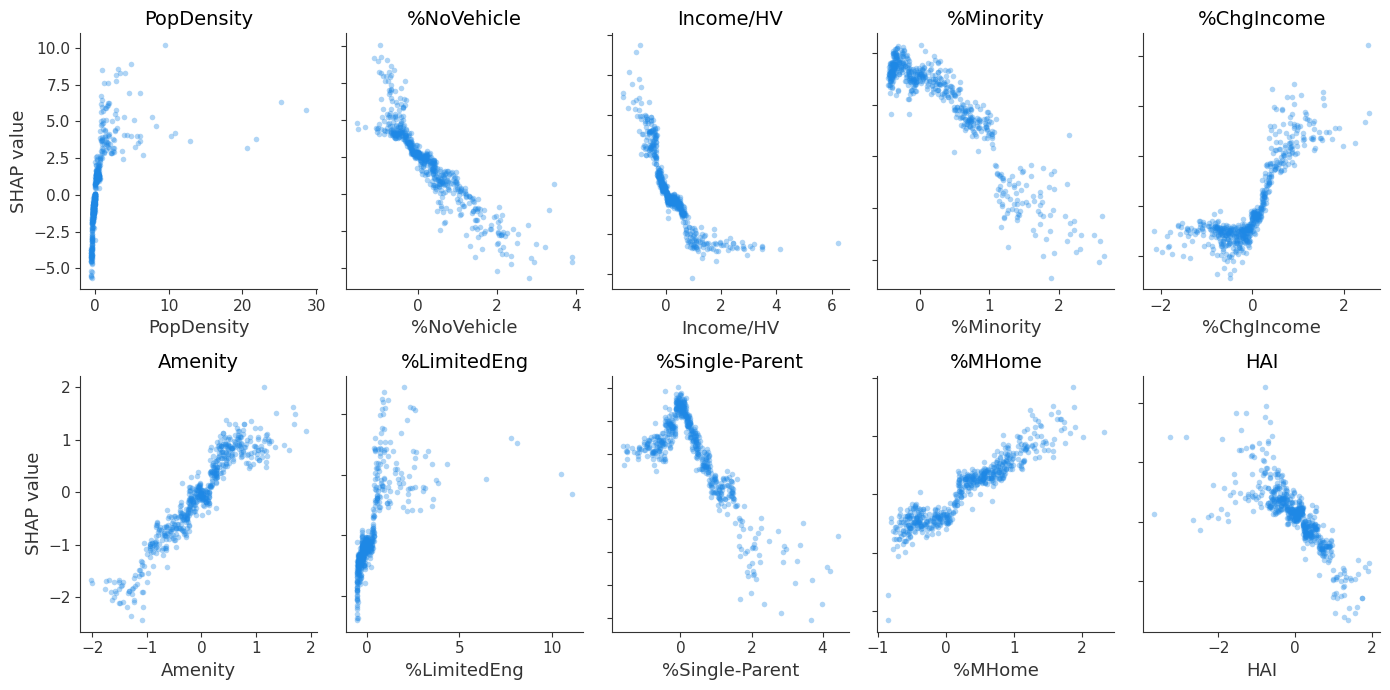

In [58]:
importance = np.abs(shap_values.values).mean(axis=0)
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()

print("Top 10 important features:", top_features)

fig, axes = plt.subplots(2, 5, figsize=(14,7))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
    if i not in [0, 5]:  
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])
    else:
        axes[i].set_ylabel("SHAP value")
    axes[i].set_title(feature, fontsize=14)
# plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig(r"F:\LongMig2025\results\maps\automl\dependece_tornado_high_0910.png", dpi=600, bbox_inches='tight')
plt.show()

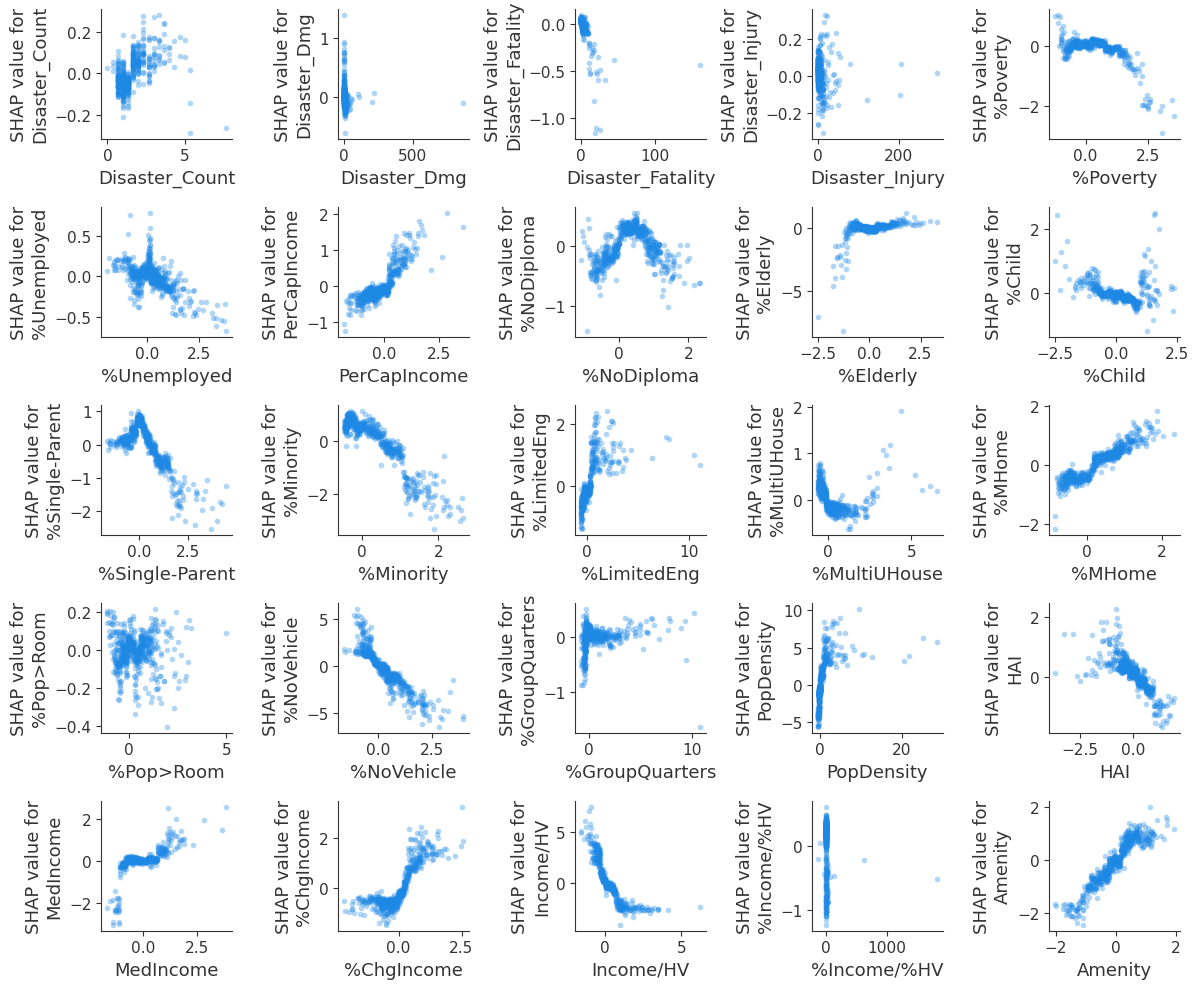

In [59]:
# Get all feature names
all_features = X.columns.tolist()

# Grid layout setup
num_features = len(all_features)
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12,10))
axes = axes.flatten()

# Loop through each feature to create a SHAP dependence plot in its subplot
for i, feature in enumerate(all_features):
    shap.dependence_plot(
        feature,
        shap_values.values,
        X,
        ax=axes[i],
        interaction_index=None,  # Ensures no color gradient (blue dots only)
        show=False,
        alpha=0.35
    )
#     axes[i].set_title(f"{feature}", fontsize=10)
# Hide any unused subplot areas
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Final layout and output
plt.tight_layout()
plt.show()

In [60]:
url = "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip"
gdf_county = gpd.read_file(url)

# 保留常用列
gdf_county = gdf_county[['STATEFP', 'COUNTYFP', 'GEOID', 'NAME', 'geometry']]
gdf_county.head()

,STATEFP,COUNTYFP,GEOID,NAME,geometry
0,31,039,31039,Cuming,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
1,53,069,53069,Wahkiakum,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,35011,De Baca,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,31109,Lancaster,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,31129,Nuckolls,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


In [61]:
gdf_county["FIPS"] = gdf_county["GEOID"]
gdf_county["FIPS"]  = gdf_county["FIPS"].astype(str).str.rjust(5,"0")

In [62]:
county_used = gdf_county

In [63]:
shap_gdf_hurricane = pd.merge(shap_df_hurricane,county_used,on="FIPS",how="inner")
shap_gdf_hurricane = gpd.GeoDataFrame(shap_gdf_hurricane,geometry="geometry")
shap_gdf_hurricane.to_file(r"F:\LongMig2025\results\maps\automl\hurricane_shap_high_0918.shp")

In [64]:
shap_gdf_flood = pd.merge(shap_df_flood,county_used,on="FIPS",how="inner")
shap_gdf_flood = gpd.GeoDataFrame(shap_gdf_flood,geometry="geometry")
shap_gdf_flood.to_file(r"F:\LongMig2025\results\maps\automl\flood_shap_high_0918.shp")

In [65]:
shap_gdf_wildfire = pd.merge(shap_df_wildfire,county_used,on="FIPS",how="inner")
shap_gdf_wildfire = gpd.GeoDataFrame(shap_gdf_wildfire,geometry="geometry")
shap_gdf_wildfire.to_file(r"F:\LongMig2025\results\maps\automl\wildfire_shap_high_0918.shp")

In [66]:
shap_gdf_tornado = pd.merge(shap_df_tornado,county_used,on="FIPS",how="inner")
shap_gdf_tornado = gpd.GeoDataFrame(shap_gdf_tornado,geometry="geometry")
shap_gdf_tornado.to_file(r"F:\LongMig2025\results\maps\automl\tornado_shap_high_0918.shp")

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
from shapely.geometry import Point

def plot_shap_maps_clipped_with_cities(gdf, features, output_prefix="SHAP_map"):
    if output_prefix == "Flood_SHAP":
        cities = {
            "New York": (-74.006, 40.7128),
            "Los Angeles": (-118.2437, 34.0522),
            "Chicago": (-87.6298, 41.8781),
            "Houston": (-95.3698, 29.7604),
            "Atlanta": (-84.3880, 33.7490),
            "Washington": (-77.0369, 38.9072),
            "Dallas": (-96.7970, 32.7767),
            "Denver": (-104.9903, 39.7392),
            "San Francisco": (-122.4194, 37.7749),
            "Seattle": (-122.3321, 47.6062),
            "Boston": (-71.0589, 42.3601),
            "Miami": (-80.1918, 25.7617),
        }
    else:
        cities = {
            "New York": (-74.006, 40.7128),
            "Houston": (-95.3698, 29.7604),
            "Atlanta": (-84.3880, 33.7490),
            "Washington": (-77.0369, 38.9072),
            "Boston": (-71.0589, 42.3601),
            "Miami": (-80.1918, 25.7617),
        }        

    # 转换城市点为GeoDataFrame
    cities_gdf = gpd.GeoDataFrame(
        list(cities.keys()),
        columns=['city'],
        geometry=[Point(xy) for xy in cities.values()],
        crs="EPSG:4326"
    )

    gdf_web = gdf.to_crs(epsg=5070)
    cities_web = cities_gdf.to_crs(epsg=5070)

    for feature in features:
        vals = gdf_web[feature].dropna()

        vmax_q = np.percentile(np.abs(vals), 75)
        vmin = -vmax_q
        vmax = vmax_q

        fig, ax = plt.subplots(1, 1, figsize=(11, 7))
        gdf_web.plot(
            column=feature,
            cmap='coolwarm',
            ax=ax,
            legend=True,
            vmin=vmin,
            vmax=vmax,
            legend_kwds={
                'label': "SHAP Value",
                'shrink': 0.6
            },
            missing_kwds={"color": "lightgrey"}
        )

        # 添加城市标注
        cities_web.plot(ax=ax, color='black', markersize=10, zorder=5)
        for x, y, label in zip(cities_web.geometry.x, cities_web.geometry.y, cities_web['city']):
            ax.text(x, y, label, fontsize=9, color='black')

#         添加底图
        ctx.add_basemap(
            ax=ax,
            crs=gdf_web.crs.to_string(),
            source=ctx.providers.CartoDB.Positron,
            alpha=0.4
        )

        ax.set_title(f"{feature} - SHAP values", fontsize=15)
        ax.axis('off')

        plt.tight_layout()
        if feature == "Income/HValue":
            feature = "IncomedivHValue"
        plt.savefig(f"F:/LongMig2025/results/maps/automl/{output_prefix}_{feature}_high_0910.png", dpi=600, bbox_inches='tight')
        plt.show()


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
from shapely.geometry import Point
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as pe
from pathlib import Path
def plot_shap_maps_clipped_with_cities(gdf, features, output_prefix="SHAP_map"):
    # 城市列表（Flood 和其他保持你原有逻辑）
    if output_prefix == "Flood_SHAP":
        cities = {
            "New York": (-74.006, 40.7128),
            "Los Angeles": (-118.2437, 34.0522),
            "Chicago": (-87.6298, 41.8781),
            "Houston": (-95.3698, 29.7604),
            "Atlanta": (-84.3880, 33.7490),
            "Washington": (-77.0369, 38.9072),
            "Dallas": (-96.7970, 32.7767),
            "Denver": (-104.9903, 39.7392),
            "San Francisco": (-122.4194, 37.7749),
            "Seattle": (-122.3321, 47.6062),
            "Boston": (-71.0589, 42.3601),
            "Miami": (-80.1918, 25.7617),
        }
    else:
        cities = {
            "New York": (-74.006, 40.7128),
            "Houston": (-95.3698, 29.7604),
            "Atlanta": (-84.3880, 33.7490),
            "Washington": (-77.0369, 38.9072),
            "Boston": (-71.0589, 42.3601),
            "Miami": (-80.1918, 25.7617),
        }

    # 文字偏移（单位：目标投影下的米）——可按需要继续微调
    default_dx, default_dy = 25000, 18000
    offset_override = {
        "New York": (30000, 25000),
        "Los Angeles": (35000, -15000),
        "San Francisco": (20000, 18000),
        "Boston": (28000, 22000),
        "Washington": (26000, -12000),
        "Miami": (20000, 18000),
        "Seattle": (22000, -12000),
        "Dallas": (25000, 20000),
        "Houston": (26000, -14000),
        "Chicago": (26000, 20000),
        "Atlanta": (22000, -14000),
        "Denver": (22000, 20000),
    }

    # 构造城市GeoDataFrame
    cities_gdf = gpd.GeoDataFrame(
        list(cities.keys()),
        columns=['city'],
        geometry=[Point(xy) for xy in cities.values()],
        crs="EPSG:4326"
    )

    # 统一到等面积投影（你原来使用 5070）
    gdf_web = gdf.to_crs(epsg=5070)
    cities_web = cities_gdf.to_crs(epsg=5070)

    for feature in features:
        vals = gdf_web[feature].dropna()

        # 使用对称分位缩放，保证0居中
        vmax_q = np.percentile(np.abs(vals), 75)
        vmin, vmax = -vmax_q, vmax_q
        norm = Normalize(vmin=vmin, vmax=vmax)
        cmap = 'coolwarm'

        fig, ax = plt.subplots(figsize=(11, 7))

        # 主图
        gdf_web.plot(
            column=feature,
            cmap=cmap,
            norm=norm,
            ax=ax,
            legend=False,                # 手工放置横向图例
            edgecolor='none',
            missing_kwds={"color": "lightgrey"}
        )

        # 城市点
        cities_web.plot(ax=ax, color='black', markersize=10, zorder=5)

        # 城市文字 + 细线连接 + 白色描边提升可读性
        for (x, y), name in zip(cities_web.geometry.apply(lambda g: (g.x, g.y)), cities_web['city']):
            dx, dy = offset_override.get(name, (default_dx, default_dy))
            ax.annotate(
                name,
                xy=(x, y),
                xytext=(x + dx, y + dy),
                textcoords='data',
                fontsize=9,
                color='black',
                ha='left', va='center',
                arrowprops=dict(arrowstyle='-', lw=0.5, color='black', alpha=0.7),
                zorder=6
            )
            # 文字描边（白色描边可以压住底图和色块）
            ax.text(x + dx, y + dy, name, fontsize=9, color='black',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='white')], alpha=0)
        boundary = gpd.read_file(r"D:\Users\xiang11\Documents\GitHub\EvacuationIan\datasets\maincounty\US_conu_county.shp")
        boundary = boundary.to_crs(epsg=5070)
        boundary.plot(ax=ax, facecolor='none',edgecolor="none", zorder=6)
        # 底图
        ctx.add_basemap(
            ax=ax,
            crs=gdf_web.crs.to_string(),
            source=ctx.providers.CartoDB.Positron,
            alpha=0.7,
            attribution_size=0
        )

        # 取消标题（满足②）
        # ax.set_title(...)  -> 不设置

        ax.axis('off')

        # —— 横向图例（放在图内底部居中）——
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        
        # inset_axes 宽度占图宽的 60%，高度为 3%
#         cb_ax = inset_axes(ax, width="60%", height="2%",
#                            loc='lower center', borderpad=1.0)
        cax = fig.add_axes([0.25, 0.05, 0.5, 0.01])
        cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_label("")
        cbar.ax.tick_params(labelsize=9)
        cax.text(1, 2, "SHAP Value", transform=cax.transAxes,
         ha='right', va='center', fontsize=9)
        plt.tight_layout()
        
#         ax.set_xlim(-7115207.647399996, 3321631.7157000005)
#         ax.set_ylim(-78232.21712266473, 6198634.671377335)
#         ax.set_aspect("equal")
#         ax.set_autoscale_on(False)


        # 文件名中的特殊替换
        fname_feature = "IncomedivHValue" if feature == "Income/HValue" else feature
        out_dir = Path(r"F:\LongMig2025\results\maps\automl\0902")  # 用 Path + 原始字符串
        out_dir.mkdir(parents=True, exist_ok=True)             # 目录不存在就创建
        out_path = out_dir / f"{output_prefix}_{fname_feature}_high_0910.png"
#         print(f"{output_prefix}_{fname_feature}:",
#               "xlim=", ax.get_xlim(), "ylim=", ax.get_ylim())
        
        plt.show()
        plt.savefig(out_path, dpi=300)
        plt.close(fig)  


In [ ]:
# features = ["Disaster_Count", "Disaster_Loss", "Income/HValue", "MedianHIncome"]
features = ["Disaster_Count", "Disaster_Dmg"]

plot_shap_maps_clipped_with_cities(shap_gdf_flood, features, output_prefix="Flood_SHAP")

In [ ]:
features = ["Disaster_Count", "Disaster_Dmg"]

plot_shap_maps_clipped_with_cities(shap_gdf_wildfire, features, output_prefix="Wildfire_SHAP")

In [ ]:
features = ["Disaster_Count", "Disaster_Dmg"]
plot_shap_maps_clipped_with_cities(shap_gdf_hurricane, features, output_prefix="Hurricane_SHAP")

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Optional, Dict, Any, Tuple

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score


def _cv_metrics(X: pd.DataFrame, y: pd.Series, folds: int = 5, random_state: int = 42) -> Dict[str, float]:
    """Compute 5-fold CV R^2 & RMSE (mean ± std) with sklearn LinearRegression."""
    cv = KFold(n_splits=folds, shuffle=True, random_state=random_state)

    r2_scores = cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2")

    try:
        rmse_scores = -cross_val_score(
            LinearRegression(), X, y, cv=cv, scoring="neg_root_mean_squared_error"
        )
    except ValueError:
        mse = -cross_val_score(
            LinearRegression(), X, y, cv=cv, scoring="neg_mean_squared_error"
        )
        rmse_scores = np.sqrt(mse)

    return {
        "R2_mean": float(np.mean(r2_scores)),
        "R2_std": float(np.std(r2_scores)),
        "RMSE_mean": float(np.mean(rmse_scores)),
        "RMSE_std": float(np.std(rmse_scores)),
    }


def _fit_sm_ols(X: pd.DataFrame, y: pd.Series) -> Tuple[Any, pd.DataFrame, Dict[str, float]]:
    """Fit statsmodels OLS and return model, tidy coef table, and fit stats."""
    Xc = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, Xc, missing="drop").fit()

    coefs = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "t": model.tvalues.values,
        "p>|t|": model.pvalues.values,
    })
    ci = model.conf_int()
    coefs["ci_lower"] = ci[0].values
    coefs["ci_upper"] = ci[1].values

    fit_stats = {
        "n_obs": int(model.nobs),
        "df_model": float(model.df_model),
        "df_resid": float(model.df_resid),
        "R2": float(model.rsquared),
        "Adj_R2": float(model.rsquared_adj),
        "RMSE_full_sample": float(np.sqrt(np.mean(model.resid ** 2))),
    }
    return model, coefs, fit_stats


def run_ols_benchmark(
    csv_path: str,
    target: str = "NMR",
    disaster_cols: Optional[List[str]] = None,
    id_like_cols: Optional[List[str]] = None,
    folds: int = 5,
    random_state: int = 42,
    save_csv: bool = True,
    output_dir: Optional[str] = None,
    output_prefix: Optional[str] = None,
) -> Dict[str, pd.DataFrame]:
    """
    Run two OLS benchmarks:
      A) Without disaster variables
      B) With all variables (including disaster variables)

    Returns dict of DataFrames:
      - cv_metrics: printed only
      - fit_stats:  full-sample OLS fit stats
      - coefficients: tidy coefficient tables
    """
    if disaster_cols is None:
        disaster_cols = ["Disaster_Count", "Disaster_Loss", "Disaster_Fatality", "Disaster_Injury"]

    if id_like_cols is None:
        id_like_cols = ["FIPS", "fips", "GEOID", "geoid", "Unnamed: 0", "Unnamed: 0.1"]

    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path)

    df = df_raw.copy()
    if target not in df.columns:
        raise ValueError(f"Target '{target}' not found in {csv_path.name} columns.")

    if not pd.api.types.is_numeric_dtype(df[target]):
        df[target] = pd.to_numeric(df[target], errors="coerce")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_cols = [c for c in numeric_cols if c in id_like_cols]
    numeric_cols = [c for c in numeric_cols if c not in drop_cols]

    if target not in numeric_cols:
        numeric_cols.append(target)
    df_num = df[numeric_cols].copy()
    df_num = df_num[~df_num[target].isna()].copy()

    def build_features(include_disaster: bool) -> List[str]:
        feats = [c for c in df_num.columns if c != target]
        if not include_disaster:
            feats = [c for c in feats if c not in disaster_cols]
        return feats

    features_A = build_features(include_disaster=False)
    X_A = df_num[features_A].dropna(axis=0, how="any").copy()
    y_A = df_num.loc[X_A.index, target].copy()

    features_B = build_features(include_disaster=True)
    X_B = df_num[features_B].dropna(axis=0, how="any").copy()
    y_B = df_num.loc[X_B.index, target].copy()

    metrics_A = _cv_metrics(X_A, y_A, folds=folds, random_state=random_state)
    metrics_A.update({"model": "OLS (No Disaster Vars)", "n": int(len(y_A)), "k_features": int(X_A.shape[1])})

    metrics_B = _cv_metrics(X_B, y_B, folds=folds, random_state=random_state)
    metrics_B.update({"model": "OLS (All Vars)", "n": int(len(y_B)), "k_features": int(X_B.shape[1])})

    cv_metrics_df = pd.DataFrame([metrics_A, metrics_B])[[
        "model", "n", "k_features", "R2_mean", "R2_std", "RMSE_mean", "RMSE_std"
    ]]

    print("\n===== Cross-validated Metrics (5-fold) =====")
    print(cv_metrics_df.round(4))

    _, coefs_A, fit_A = _fit_sm_ols(X_A, y_A)
    _, coefs_B, fit_B = _fit_sm_ols(X_B, y_B)

    fit_A.update({"model": "OLS (No Disaster Vars)"})
    fit_B.update({"model": "OLS (All Vars)"})
    fit_stats_df = pd.DataFrame([fit_A, fit_B])[[
        "model", "n_obs", "df_model", "df_resid", "R2", "Adj_R2", "RMSE_full_sample"
    ]]

    coefs_A.insert(0, "model", "OLS (No Disaster Vars)")
    coefs_B.insert(0, "model", "OLS (All Vars)")
    coefficients_df = pd.concat([coefs_A, coefs_B], ignore_index=True)

    outputs = {
        "fit_stats": fit_stats_df,
        "coefficients": coefficients_df,
    }

    if save_csv:
        out_dir = Path(output_dir) if output_dir else csv_path.parent
        out_dir.mkdir(parents=True, exist_ok=True)
        prefix = output_prefix if output_prefix else csv_path.stem

        outputs["fit_stats"].to_csv(out_dir / f"{prefix}_ols_fullsample_fitstats.csv", index=False)
        outputs["coefficients"].to_csv(out_dir / f"{prefix}_ols_coefficients.csv", index=False)

    return outputs


# --------- 示例用法 ----------
if __name__ == "__main__":
    res = run_ols_benchmark(
        csv_path=r"F:\LongMig2025\data\Regression\Flood_Regression_data_high.csv",
        target="NMR",
        disaster_cols=["Disaster_Count", "Disaster_Loss", "Disaster_Fatality", "Disaster_Injury"],
    )

    more_files = [
        r"F:\LongMig2025\data\Regression\Hurricane_Regression_data_high.csv",
        r"F:\LongMig2025\data\Regression\Wildfire_Regression_data_high.csv",
        r"F:\LongMig2025\data\Regression\Tornado_Regression_data_high.csv",
    ]
    for p in more_files:
        run_ols_benchmark(p, target="NMR", save_csv=True)
